# NeuroSense — Stroke Prediction (Trial 4 — Fixed Pipeline)

Same overall structure as the earlier `shoulder.ipynb` trial, but the methodology bugs have been fixed:

| Issue in previous trial | Fix in this notebook |
|---|---|
| `X_test` / `y_test` overwritten by a re-split of SMOTE-augmented data | Test set is preserved end-to-end and never reassigned |
| Plain SMOTE on label-encoded categoricals (gives `gender = 0.4`) | `SMOTENC` with explicit categorical indices |
| BMI / smoking imputers fit on the whole dataframe | Imputers fit on **training rows only**, then applied to test |
| Random `train_test_split` | Stratified on `stroke` so both splits keep the ~5% positive rate |
| Accuracy as headline metric on a 95/5 problem | **PR-AUC and recall on the positive class** are the metrics of record |
| Stacking `cv=30` | `cv=5` (minority class is too small for 30 folds) |
| CFS dropped BMI on Pearson correlation | Mutual information ranking; BMI explicitly retained |
| Hand-typed metric table | Built programmatically from a `results` list |
| `PowerTransformer` was dead code | Fit on training data, applied to both splits, propagates to models |

## Importing all Packages

In [11]:
import os
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    RandomizedSearchCV, cross_val_score)
from sklearn.preprocessing import (
    PolynomialFeatures, PowerTransformer, StandardScaler)
from sklearn.feature_selection import mutual_info_classif
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, StackingClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    average_precision_score, f1_score, recall_score, precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, auc)

from imblearn.over_sampling import SMOTENC

import xgboost as xgb
from xgboost import XGBClassifier

import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [12]:
# Global seeds for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

## Reading and Exploring the DataFrame

In [13]:
# Auto-load the Stroke Prediction Dataset.
#   1. Use the file if it's already attached as a Kaggle Input or sitting locally.
#   2. Otherwise pull it from Kaggle Hub at runtime (no manual upload needed).
#      Requires "Internet" to be ON in the Kaggle notebook settings.

CANDIDATE_PATHS = [
    '/kaggle/input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv',
    'stroke_dataset.csv',
    'healthcare-dataset-stroke-data.csv',
    '../input/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv',
]
csv_path = next((p for p in CANDIDATE_PATHS if os.path.exists(p)), None)

if csv_path is None:
    # Fallback: download via kagglehub (preinstalled on Kaggle)
    try:
        import kagglehub
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=True)
        import kagglehub

    download_dir = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
    print("Downloaded to:", download_dir)

    # Locate the CSV inside the downloaded folder
    for root, _, files in os.walk(download_dir):
        for f in files:
            if f.lower().endswith(".csv"):
                csv_path = os.path.join(root, f)
                break
        if csv_path:
            break

assert csv_path is not None, 'Could not locate the dataset (turn on Internet in Kaggle notebook settings).'
print('Loading from:', csv_path)

original_df = pd.read_csv(csv_path)
df = original_df.copy()
df.shape

Downloaded to: /kaggle/input/datasets/fedesoriano/stroke-prediction-dataset
Loading from: /kaggle/input/datasets/fedesoriano/stroke-prediction-dataset/healthcare-dataset-stroke-data.csv


(5110, 12)

In [14]:
df.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [15]:
df.tail(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5100,68398,Male,82.0,1,0,Yes,Self-employed,Rural,71.97,28.3,never smoked,0
5101,36901,Female,45.0,0,0,Yes,Private,Urban,97.95,24.5,Unknown,0
5102,45010,Female,57.0,0,0,Yes,Private,Rural,77.93,21.7,never smoked,0
5103,22127,Female,18.0,0,0,No,Private,Urban,82.85,46.9,Unknown,0
5104,14180,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [17]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [18]:
df.duplicated().any()

np.False_

Some versions of the CSV use the string `"N/A"` in `bmi` instead of a real `NaN`. Coerce to numeric.

In [19]:
df['bmi'] = pd.to_numeric(df['bmi'], errors='coerce')
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

## Data Preprocessing

### Boxplot & IQR Method (Interquartile Range)

In [20]:
continuous_features = ['age', 'avg_glucose_level', 'bmi']

In [21]:
Q1 = df[continuous_features].quantile(0.25)
Q3 = df[continuous_features].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
pd.concat([lower_bound.rename("lower"), upper_bound.rename("upper")], axis=1)

,lower,upper
age,-29.0000,115.0000
avg_glucose_level,21.9775,169.3575
bmi,9.1000,47.5000


In [22]:
for feature in continuous_features:
    mask = (df[feature] < lower_bound[feature]) | (df[feature] > upper_bound[feature])
    print(f"Outliers in {feature}: {mask.sum()}")

Outliers in age: 0
Outliers in avg_glucose_level: 627
Outliers in bmi: 110


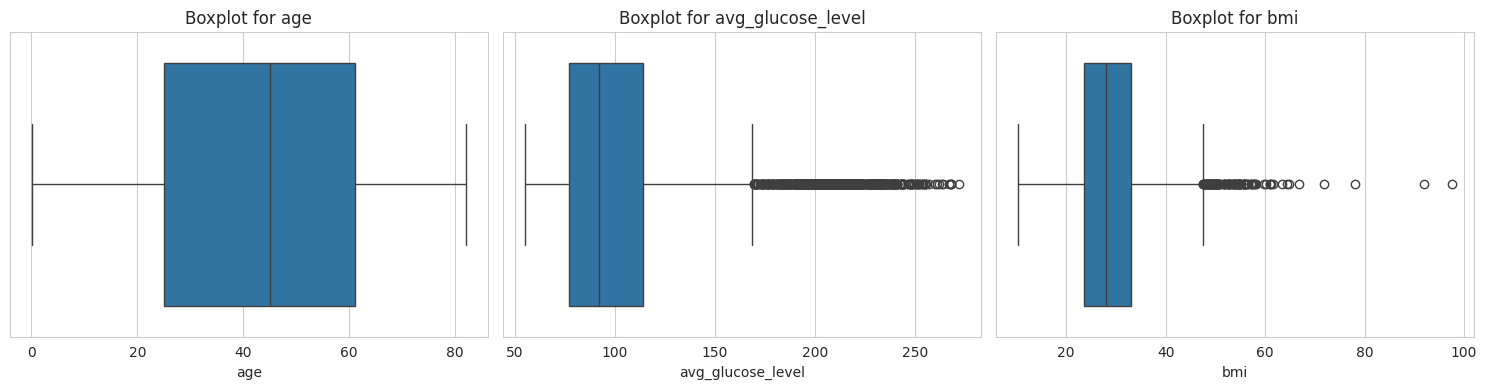

In [23]:
fig, axes = plt.subplots(1, len(continuous_features), figsize=(15, 4))
for i, feature in enumerate(continuous_features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(f"Boxplot for {feature}")
plt.tight_layout()
plt.show()

We **keep** the IQR-flagged points: extreme glucose / BMI values are clinically meaningful (diabetes, severe obesity). Removing them throws away the very signal we want to model.

### Z-score Method (Standard Deviation)

In [24]:
# Fill missing temporarily so zscore can compute
tmp = df[continuous_features].fillna(df[continuous_features].mean())
z_scores = zscore(tmp)
outlier_mask = (np.abs(z_scores) > 3).any(axis=1)
print(f"Number of |z| > 3 rows: {outlier_mask.sum()}")

Number of |z| > 3 rows: 108


Z-score is more conservative than IQR. Same reasoning — we keep them.

### Conversion to the appropriate datatypes

In [25]:
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].astype("category")

df["age"] = df["age"].astype("int64")  # came in as float
df.dtypes

id                      int64
gender               category
age                     int64
hypertension            int64
heart_disease           int64
ever_married         category
work_type            category
Residence_type       category
avg_glucose_level     float64
bmi                   float64
smoking_status       category
stroke                  int64
dtype: object

### Filter under-18s

Stroke risk in this dataset is overwhelmingly an adult phenomenon and the under-18 segment is sparse. Drop them so the model focuses on the relevant population.

In [26]:
print("Under-18 rows:", (df["age"] < 18).sum())
df = df[df["age"] >= 18].reset_index(drop=True)
df.shape

Under-18 rows: 856


(4254, 12)

### Drop irrelevant columns and the singleton "Other" gender

In [27]:
df = df.drop(columns=["id"])
print("Gender counts:")
print(df["gender"].value_counts())
df = df[df["gender"] != "Other"].copy()
df["gender"] = df["gender"].cat.remove_unused_categories()
df.shape

Gender counts:
gender
Female    2576
Male      1677
Other        1
Name: count, dtype: int64


(4253, 11)

### Encode categoricals to integer codes

Mirrors the original notebook (label encoding). We track which column indices are categorical so `SMOTENC` handles them correctly later.

In [28]:
# Manual label-encoding maps so we control the meaning of each integer
gender_map    = {"Male": 0, "Female": 1}
married_map   = {"No": 0, "Yes": 1}
work_map      = {"Govt_job": 0, "Never_worked": 1, "Private": 2, "Self-employed": 3, "children": 4}
residence_map = {"Rural": 0, "Urban": 1}
smoking_map   = {"never smoked": 0, "formerly smoked": 1, "smokes": 2}

df["gender"]         = df["gender"].astype(str).map(gender_map)
df["ever_married"]   = df["ever_married"].astype(str).map(married_map)
df["work_type"]      = df["work_type"].astype(str).map(work_map)
df["Residence_type"] = df["Residence_type"].astype(str).map(residence_map)
# Smoking: keep "Unknown" as NaN so we can impute it
df["smoking_status"] = df["smoking_status"].astype(str).map(smoking_map)

df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67,0,1,1,2,1,228.69,36.6,1.0,1
1,1,61,0,0,1,3,0,202.21,NaN,0.0,1
2,0,80,0,1,1,2,0,105.92,32.5,0.0,1
3,1,49,0,0,1,2,1,171.23,34.4,2.0,1
4,1,79,1,0,1,3,0,174.12,24.0,0.0,1


In [29]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  181
smoking_status       862
stroke                 0
dtype: int64

## Train / Test Split (BEFORE imputation — the critical fix)

In the previous trial, BMI and smoking were imputed using a model fit on the *whole* dataframe — including rows that later end up in the test set. That leaks test data into the imputer.

Here we split first, then fit imputers on training rows only. We also `stratify=y` so the ~5% stroke rate is preserved in both splits.

In [30]:
TARGET = "stroke"
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Train: {X_train.shape}   stroke rate = {y_train.mean():.4f}")
print(f"Test : {X_test.shape}    stroke rate = {y_test.mean():.4f}")

Train: (3402, 10)   stroke rate = 0.0582
Test : (851, 10)    stroke rate = 0.0576


## Predicting missing BMI

Decision Tree regressor predicts BMI from `gender` + `age`, fit only on training rows where BMI is observed.

In [31]:
bmi_train_known = X_train[X_train["bmi"].notna()]
bmi_X = bmi_train_known[["gender", "age"]]
bmi_y = bmi_train_known["bmi"]

bmi_model = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
bmi_model.fit(bmi_X, bmi_y)

# Apply the SAME fitted model to both splits
for split_name, split in [("X_train", X_train), ("X_test", X_test)]:
    miss = split["bmi"].isna()
    if miss.any():
        split.loc[miss, "bmi"] = bmi_model.predict(split.loc[miss, ["gender", "age"]])
    print(f"{split_name}: missing bmi after = {split['bmi'].isna().sum()}")

X_train: missing bmi after = 0
X_test: missing bmi after = 0


## Predicting unknown smoking status

Decision Tree classifier predicts smoking class from `age` + `work_type`, again fit only on training rows where smoking is observed.

In [32]:
smoke_train_known = X_train[X_train["smoking_status"].notna()]
sm_X = smoke_train_known[["age", "work_type"]]
sm_y = smoke_train_known["smoking_status"].astype(int)

smoke_model = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
smoke_model.fit(sm_X, sm_y)

for split_name, split in [("X_train", X_train), ("X_test", X_test)]:
    miss = split["smoking_status"].isna()
    if miss.any():
        split.loc[miss, "smoking_status"] = smoke_model.predict(split.loc[miss, ["age", "work_type"]])
    print(f"{split_name}: missing smoking after = {split['smoking_status'].isna().sum()}")

X_train["smoking_status"] = X_train["smoking_status"].astype(int)
X_test["smoking_status"]  = X_test["smoking_status"].astype(int)

X_train: missing smoking after = 0
X_test: missing smoking after = 0


## Univariate Analysis

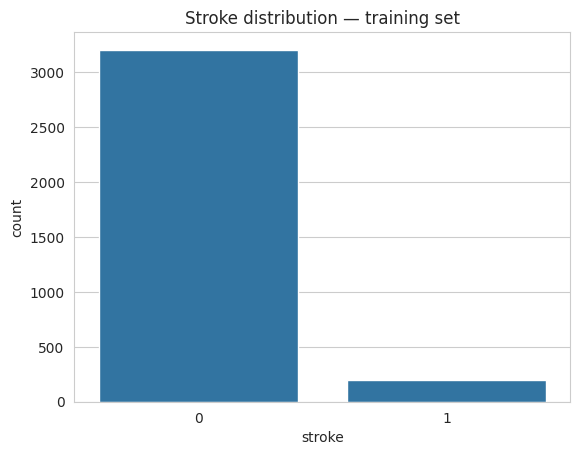

stroke
0    94.18
1     5.82
Name: proportion, dtype: float64


In [33]:
# Reattach the target for easier plotting on training data
df_train = X_train.copy()
df_train["stroke"] = y_train.values

sns.countplot(x="stroke", data=df_train)
plt.title("Stroke distribution — training set")
plt.show()

print(df_train["stroke"].value_counts(normalize=True).mul(100).round(2))

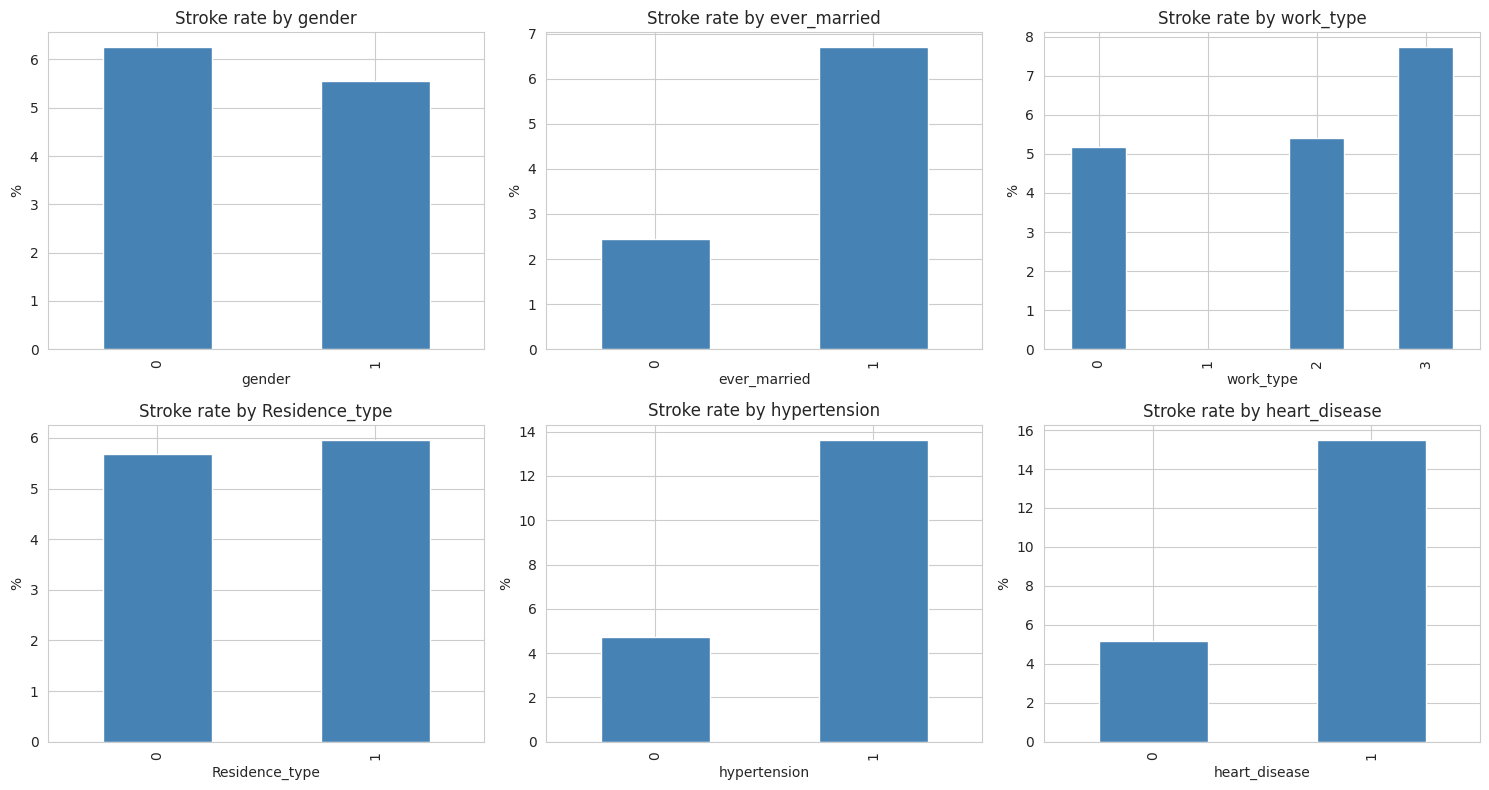

In [34]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(),
                   ["gender", "ever_married", "work_type", "Residence_type", "hypertension", "heart_disease"]):
    rate = df_train.groupby(col)["stroke"].mean() * 100
    rate.plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(f"Stroke rate by {col}")
    ax.set_ylabel("%")
plt.tight_layout(); plt.show()

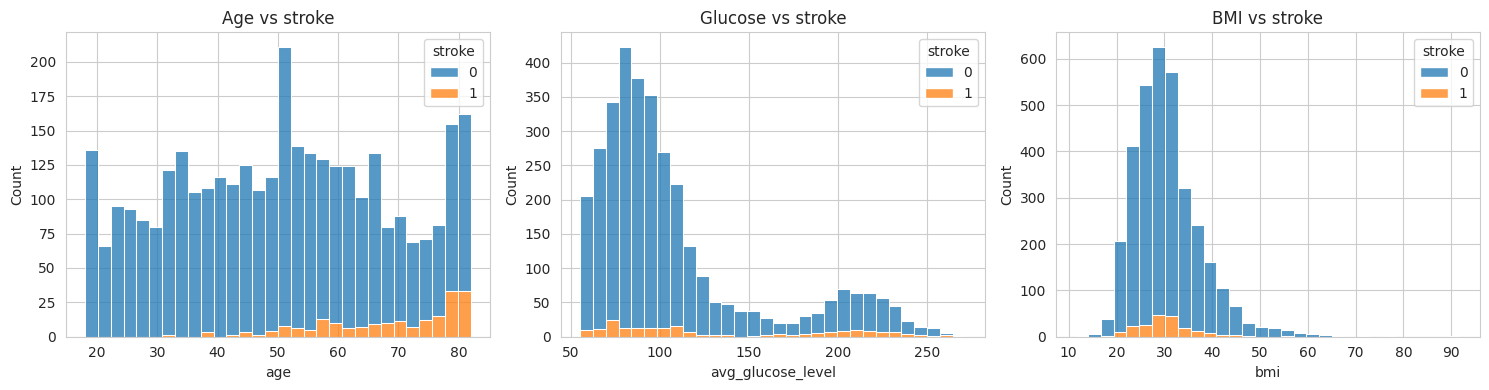

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(data=df_train, x="age", hue="stroke", bins=30, ax=axes[0], multiple="stack")
axes[0].set_title("Age vs stroke")
sns.histplot(data=df_train, x="avg_glucose_level", hue="stroke", bins=30, ax=axes[1], multiple="stack")
axes[1].set_title("Glucose vs stroke")
sns.histplot(data=df_train, x="bmi", hue="stroke", bins=30, ax=axes[2], multiple="stack")
axes[2].set_title("BMI vs stroke")
plt.tight_layout(); plt.show()

## Bivariate / Multivariate Analysis

### Correlation Analysis

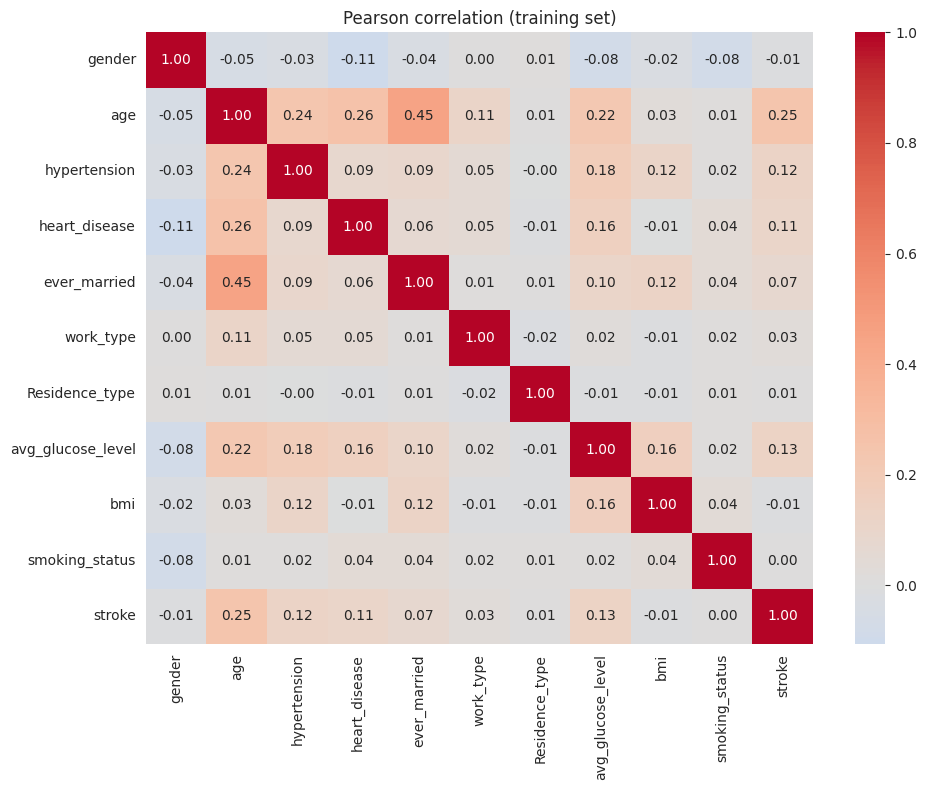


Absolute Pearson correlation with stroke:
age                  0.249634
avg_glucose_level    0.127448
hypertension         0.123581
heart_disease        0.106776
ever_married         0.073449
work_type            0.027751
gender               0.014693
bmi                  0.010341
Residence_type       0.006099
smoking_status       0.003966
Name: stroke, dtype: float64


In [36]:
plt.figure(figsize=(10, 8))
cor = df_train.corr()
sns.heatmap(cor, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Pearson correlation (training set)")
plt.tight_layout()
plt.show()

cor_with_target = cor["stroke"].drop("stroke").abs().sort_values(ascending=False)
print("\nAbsolute Pearson correlation with stroke:")
print(cor_with_target)

### Correlation-based Feature Selection (CFS) — Mutual Information

Pearson catches linear relationships only. Mutual information captures non-linear effects too — which is why BMI gets a fairer assessment here than in the previous trial.

Mutual information with stroke:
age                  0.037003
bmi                  0.012308
hypertension         0.005955
heart_disease        0.004133
avg_glucose_level    0.004065
ever_married         0.003244
smoking_status       0.001468
work_type            0.000851
gender               0.000107
Residence_type       0.000019
dtype: float64


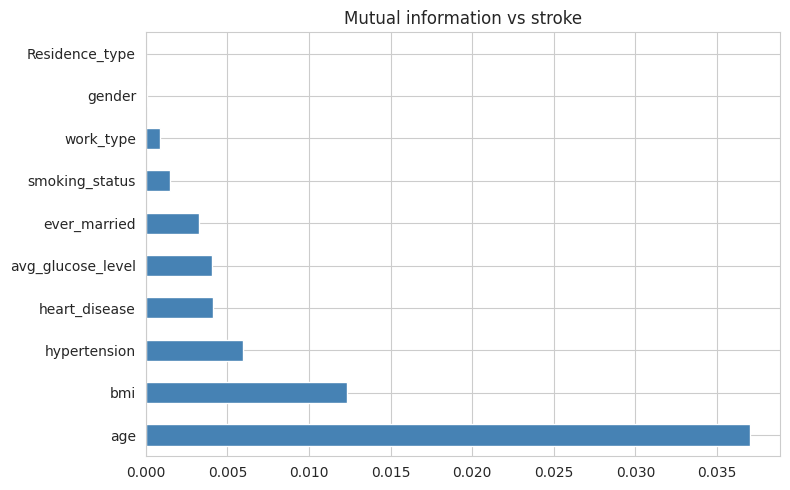

In [37]:
discrete_mask = [c in ["gender","hypertension","heart_disease","ever_married",
                       "work_type","Residence_type","smoking_status"]
                 for c in X_train.columns]

mi_scores = mutual_info_classif(
    X_train, y_train, discrete_features=discrete_mask, random_state=RANDOM_STATE)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print("Mutual information with stroke:")
print(mi_series)

mi_series.plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("Mutual information vs stroke")
plt.tight_layout(); plt.show()

In [38]:
# Keep the top features by MI. We deliberately keep BMI even if MI ranks it just
# outside the top K — the previous trial dropped it and it cost performance.
TOP_K = 9
selected_features = mi_series.head(TOP_K).index.tolist()
if "bmi" not in selected_features:
    selected_features = selected_features[:-1] + ["bmi"]

print("Selected features:", selected_features)

X_train = X_train[selected_features].reset_index(drop=True)
X_test  = X_test[selected_features].reset_index(drop=True)

Selected features: ['age', 'bmi', 'hypertension', 'heart_disease', 'avg_glucose_level', 'ever_married', 'smoking_status', 'work_type', 'gender']


## Feature Engineering — Polynomial Features

Polynomial transformation on the continuous numeric columns. **Fit on training data, transform test data** — the test set never influences feature construction.

In [39]:
numerical_features = [c for c in ["age", "avg_glucose_level", "bmi"] if c in X_train.columns]
print("Polynomial-expanding:", numerical_features)

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)

poly_train = poly.fit_transform(X_train[numerical_features])
poly_test  = poly.transform(X_test[numerical_features])

poly_cols = list(poly.get_feature_names_out(numerical_features))
print("Generated polynomial columns:", poly_cols)

Polynomial-expanding: ['age', 'avg_glucose_level', 'bmi']
Generated polynomial columns: ['age', 'avg_glucose_level', 'bmi', 'age^2', 'age avg_glucose_level', 'age bmi', 'avg_glucose_level^2', 'avg_glucose_level bmi', 'bmi^2']


In [40]:
X_train_eng = pd.concat([
    X_train.drop(columns=numerical_features).reset_index(drop=True),
    pd.DataFrame(poly_train, columns=poly_cols)],
    axis=1)
X_test_eng = pd.concat([
    X_test.drop(columns=numerical_features).reset_index(drop=True),
    pd.DataFrame(poly_test, columns=poly_cols)],
    axis=1)

print("After feature engineering:")
print("  X_train_eng:", X_train_eng.shape)
print("  X_test_eng :", X_test_eng.shape)
X_train_eng.head()

After feature engineering:
  X_train_eng: (3402, 15)
  X_test_eng : (851, 15)


,hypertension,heart_disease,ever_married,smoking_status,work_type,gender,age,avg_glucose_level,bmi,age^2,age avg_glucose_level,age bmi,avg_glucose_level^2,avg_glucose_level bmi,bmi^2
0,0,0,1,1,0,1,32.0,101.13,43.9,1024.0,3236.16,1404.8,10227.2769,4439.607,1927.21
1,0,0,0,0,0,1,37.0,76.21,20.4,1369.0,2819.77,754.8,5807.9641,1554.684,416.16
2,0,0,1,0,3,1,78.0,56.95,26.0,6084.0,4442.10,2028.0,3243.3025,1480.700,676.00
3,0,0,1,0,0,1,58.0,109.56,23.1,3364.0,6354.48,1339.8,12003.3936,2530.836,533.61
4,0,0,1,2,0,1,66.0,200.49,34.6,4356.0,13232.34,2283.6,40196.2401,6936.954,1197.16


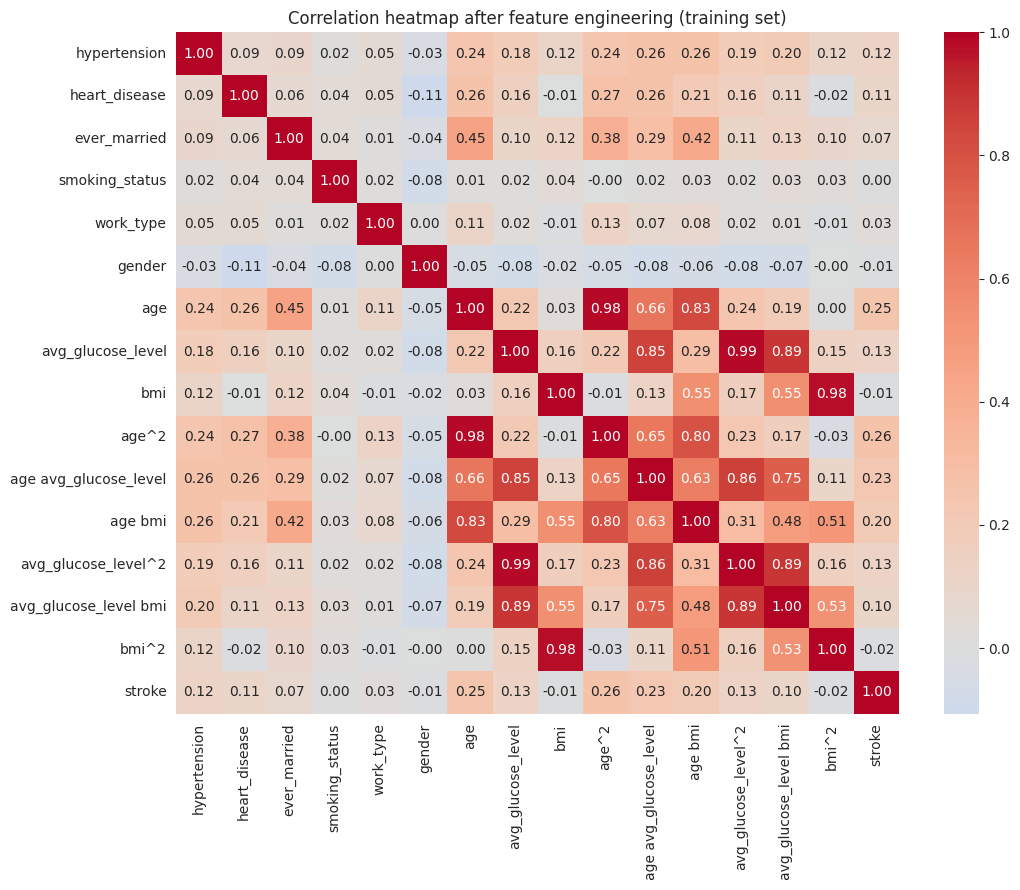

In [41]:
plt.figure(figsize=(11, 9))
sns.heatmap(
    pd.concat([X_train_eng, y_train.rename("stroke")], axis=1).corr(),
    annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation heatmap after feature engineering (training set)")
plt.tight_layout(); plt.show()

## Imbalance handling — SMOTENC

The previous trial used plain SMOTE on label-encoded categoricals, producing synthetic patients with `gender = 0.4`. `SMOTENC` knows which columns are categorical and chooses a discrete mode value for those, while interpolating numerics normally.

Applied **only to training data**.

In [42]:
# Categorical columns survive feature engineering unchanged; numerical ones
# went into the polynomial block.
cat_cols    = [c for c in X_train_eng.columns if c not in poly_cols]
cat_indices = [X_train_eng.columns.get_loc(c) for c in cat_cols]
print("Categorical columns:", cat_cols)
print("Categorical indices:", cat_indices)

Categorical columns: ['hypertension', 'heart_disease', 'ever_married', 'smoking_status', 'work_type', 'gender']
Categorical indices: [0, 1, 2, 3, 4, 5]


Before SMOTENC:
stroke
0    3204
1     198
Name: count, dtype: int64

After SMOTENC:
stroke
0    3204
1    3204
Name: count, dtype: int64


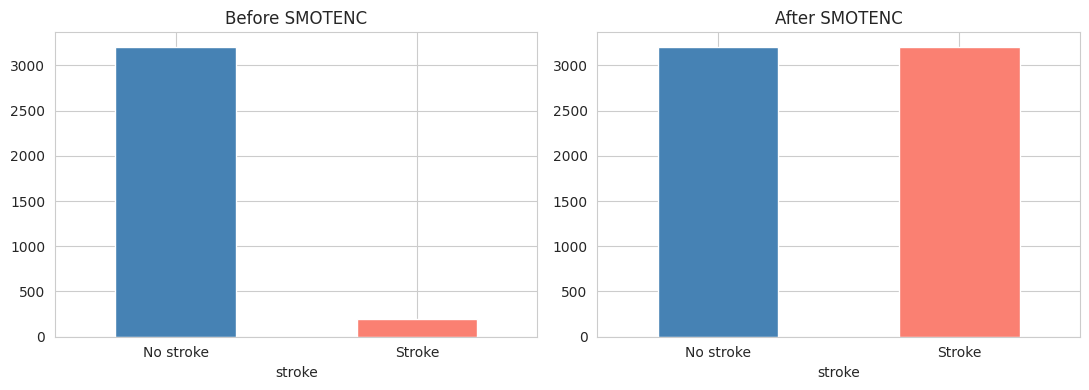

In [43]:
print("Before SMOTENC:")
print(y_train.value_counts())

smote_nc = SMOTENC(categorical_features=cat_indices, random_state=RANDOM_STATE)
X_train_res, y_train_res = smote_nc.fit_resample(X_train_eng, y_train)

print("\nAfter SMOTENC:")
print(y_train_res.value_counts())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
y_train.value_counts().plot(kind="bar", ax=ax[0], color=["steelblue", "salmon"])
ax[0].set_title("Before SMOTENC")
ax[0].set_xticklabels(["No stroke", "Stroke"], rotation=0)
y_train_res.value_counts().plot(kind="bar", ax=ax[1], color=["steelblue", "salmon"])
ax[1].set_title("After SMOTENC")
ax[1].set_xticklabels(["No stroke", "Stroke"], rotation=0)
plt.tight_layout(); plt.show()

## Power Transformation + Standard Scaling

Yeo-Johnson power transformation makes age/glucose/BMI distributions roughly Gaussian; StandardScaler centres and scales. **Both fit on training data only and applied to test.**

In [44]:
features_to_transform = list(poly_cols)

# 1) PowerTransformer
pt = PowerTransformer(method="yeo-johnson")
X_train_res[features_to_transform] = pt.fit_transform(X_train_res[features_to_transform])
X_test_eng[features_to_transform]  = pt.transform(X_test_eng[features_to_transform])

# 2) StandardScaler
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_res),
                              columns=X_train_res.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test_eng),
                              columns=X_test_eng.columns)

print("Final shapes:")
print(f"  X_train_scaled: {X_train_scaled.shape}")
print(f"  X_test_scaled : {X_test_scaled.shape}")

Final shapes:
  X_train_scaled: (6408, 15)
  X_test_scaled : (851, 15)


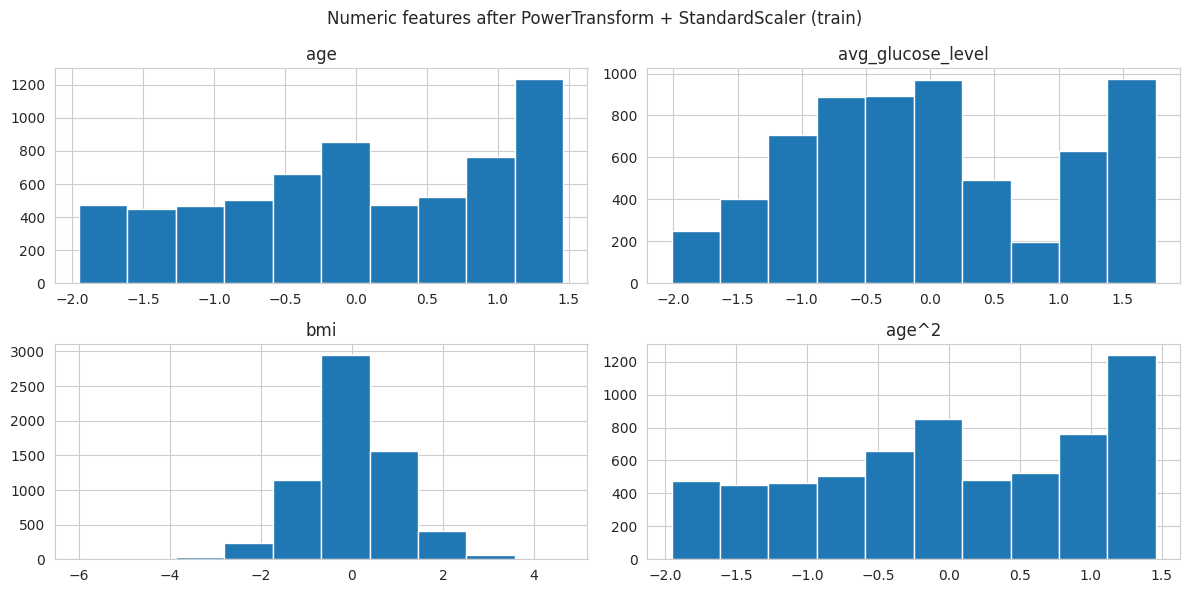

In [45]:
# Visual check that the numeric features are now ~Gaussian-ish
X_train_scaled[poly_cols[:4]].hist(figsize=(12, 6))
plt.suptitle("Numeric features after PowerTransform + StandardScaler (train)")
plt.tight_layout(); plt.show()

## Canonical training / test arrays

Everything below uses these names. **They are written ONCE here and never reassigned** — that's the bug fix vs the previous trial.

In [46]:
X_TRAIN = X_train_scaled.copy()
X_TEST  = X_test_scaled.copy()
Y_TRAIN = y_train_res.copy()
Y_TEST  = y_test.copy()

print(f"X_TRAIN: {X_TRAIN.shape}   class counts: {Y_TRAIN.value_counts().tolist()}")
print(f"X_TEST : {X_TEST.shape}    class counts: {Y_TEST.value_counts().tolist()}")
print()
print(f"Test-set positive rate (real-world): {Y_TEST.mean():.4f}")
print(f"Train-set positive rate (post-SMOTENC): {Y_TRAIN.mean():.4f}")

X_TRAIN: (6408, 15)   class counts: [3204, 3204]
X_TEST : (851, 15)    class counts: [802, 49]

Test-set positive rate (real-world): 0.0576
Train-set positive rate (post-SMOTENC): 0.5000


## Evaluation helper

PR-AUC and recall on the stroke class are the metrics that matter under 95/5 imbalance. Accuracy is reported but not used to rank models.

In [47]:
def evaluate(name, model, X_te=None, y_te=None, threshold=0.5):
    """Score a fitted model on the held-out test set."""
    if X_te is None:
        X_te = X_TEST
    if y_te is None:
        y_te = Y_TEST
    proba = model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba") else None
    pred  = (proba >= threshold).astype(int) if proba is not None else model.predict(X_te)
    out = {
        "model":         name,
        "accuracy":      accuracy_score(y_te, pred),
        "precision_pos": precision_score(y_te, pred, zero_division=0),
        "recall_pos":    recall_score(y_te, pred, zero_division=0),
        "f1_pos":        f1_score(y_te, pred, zero_division=0),
        "roc_auc":       roc_auc_score(y_te, proba) if proba is not None else np.nan,
        "pr_auc":        average_precision_score(y_te, proba) if proba is not None else np.nan,
    }
    return out, proba, pred

def show_report(name, y_te, proba, pred):
    print(f"--- {name} ---")
    print(classification_report(y_te, pred, digits=3, zero_division=0))
    if proba is not None:
        print(f"ROC-AUC: {roc_auc_score(y_te, proba):.4f}    "
              f"PR-AUC : {average_precision_score(y_te, proba):.4f}")
    cm = confusion_matrix(y_te, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No stroke", "Stroke"]).plot(values_format="d")
    plt.title(name); plt.show()

# Single results list, one entry per model — feeds the metric table at the end.
results = []

## Model Development

### Logistic Regression

--- Logistic Regression ---
              precision    recall  f1-score   support

           0      0.965     0.762     0.852       802
           1      0.124     0.551     0.202        49

    accuracy                          0.750       851
   macro avg      0.545     0.656     0.527       851
weighted avg      0.917     0.750     0.814       851

ROC-AUC: 0.7140    PR-AUC : 0.1298


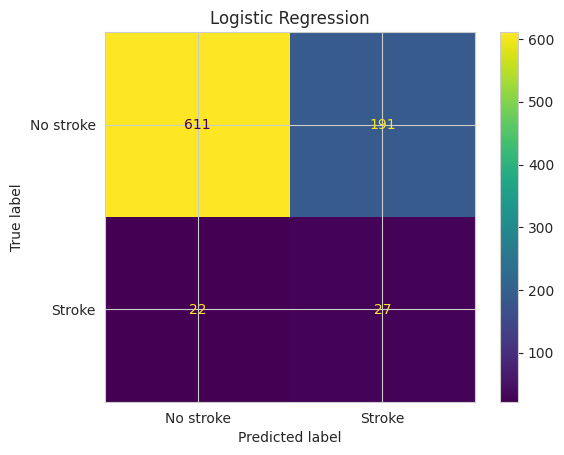

In [48]:
log_reg = LogisticRegression(class_weight="balanced", max_iter=2000, random_state=RANDOM_STATE)
log_reg.fit(X_TRAIN, Y_TRAIN)
m, proba_lr, pred_lr = evaluate("Logistic Regression", log_reg)
show_report("Logistic Regression", Y_TEST, proba_lr, pred_lr)
results.append(m)

### Hypertuning Logistic Regression

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and

Best params: {'solver': 'liblinear', 'penalty': 'l1', 'C': 10}
--- Logistic Regression (tuned) ---
              precision    recall  f1-score   support

           0      0.957     0.908     0.932       802
           1      0.178     0.327     0.230        49

    accuracy                          0.874       851
   macro avg      0.567     0.617     0.581       851
weighted avg      0.912     0.874     0.891       851

ROC-AUC: 0.7499    PR-AUC : 0.1352


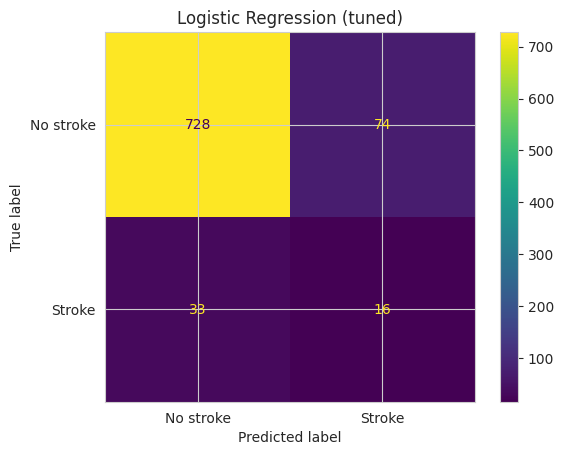

In [49]:
param_dist_logreg = [
    {"C": [0.001, 0.01, 0.1, 1, 10],
     "penalty": ["l1", "l2"], "solver": ["liblinear"]},
    {"C": [0.001, 0.01, 0.1, 1, 10],
     "penalty": ["l2", None], "solver": ["lbfgs"]},
]

random_search_logreg = RandomizedSearchCV(
    LogisticRegression(class_weight="balanced", max_iter=5000, random_state=RANDOM_STATE),
    param_distributions=param_dist_logreg,
    n_iter=10, cv=5, scoring="average_precision",  # tune on PR-AUC
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_logreg.fit(X_TRAIN, Y_TRAIN)
best_logreg = random_search_logreg.best_estimator_
print("Best params:", random_search_logreg.best_params_)

m, proba, pred = evaluate("Logistic Regression (tuned)", best_logreg)
show_report("Logistic Regression (tuned)", Y_TEST, proba, pred)
results.append(m)

### Random Forest Classifier

--- Random Forest ---
              precision    recall  f1-score   support

           0      0.946     0.926     0.936       802
           1      0.106     0.143     0.122        49

    accuracy                          0.881       851
   macro avg      0.526     0.535     0.529       851
weighted avg      0.898     0.881     0.889       851

ROC-AUC: 0.7573    PR-AUC : 0.1176


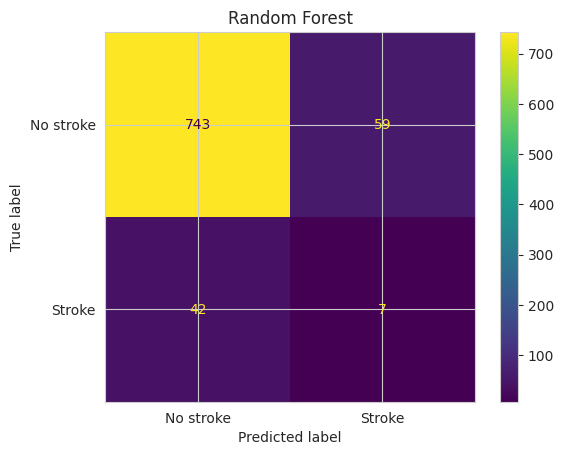

In [50]:
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced",
                            n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_TRAIN, Y_TRAIN)
m, proba, pred = evaluate("Random Forest", rf)
show_report("Random Forest", Y_TEST, proba, pred)
results.append(m)

### Hypertuning Random Forest

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'log2', 'max_depth': None}
--- Random Forest (tuned) ---
              precision    recall  f1-score   support

           0      0.946     0.926     0.936       802
           1      0.106     0.143     0.122        49

    accuracy                          0.881       851
   macro avg      0.526     0.535     0.529       851
weighted avg      0.898     0.881     0.889       851

ROC-AUC: 0.7573    PR-AUC : 0.1176


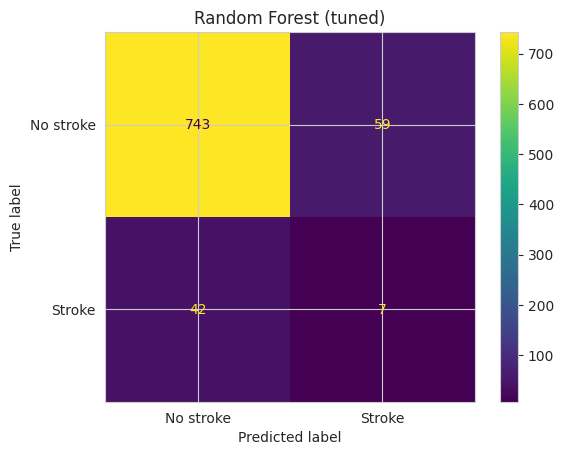

In [51]:
param_dist_rf = {
    "n_estimators": [100, 200, 400],
    "max_depth":    [None, 6, 12, 20],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", "log2"],
}

random_search_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_dist_rf,
    n_iter=10, cv=5, scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_rf.fit(X_TRAIN, Y_TRAIN)
best_rf = random_search_rf.best_estimator_
print("Best params:", random_search_rf.best_params_)

m, proba, pred = evaluate("Random Forest (tuned)", best_rf)
show_report("Random Forest (tuned)", Y_TEST, proba, pred)
results.append(m)

### Support Vector Machine

--- SVM ---
              precision    recall  f1-score   support

           0      0.954     0.829     0.887       802
           1      0.110     0.347     0.167        49

    accuracy                          0.801       851
   macro avg      0.532     0.588     0.527       851
weighted avg      0.906     0.801     0.846       851

ROC-AUC: 0.6936    PR-AUC : 0.1107


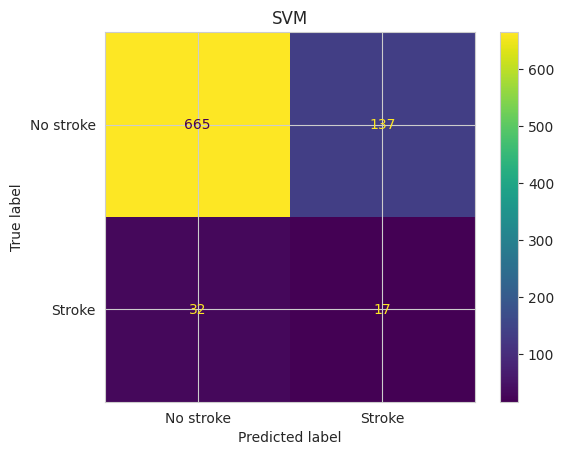

In [52]:
svm = SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE)
svm.fit(X_TRAIN, Y_TRAIN)
m, proba, pred = evaluate("SVM", svm)
show_report("SVM", Y_TEST, proba, pred)
results.append(m)

### Hypertuning SVM

Best params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
--- SVM (tuned) ---
              precision    recall  f1-score   support

           0      0.954     0.850     0.899       802
           1      0.118     0.327     0.173        49

    accuracy                          0.820       851
   macro avg      0.536     0.588     0.536       851
weighted avg      0.906     0.820     0.857       851

ROC-AUC: 0.7020    PR-AUC : 0.1027


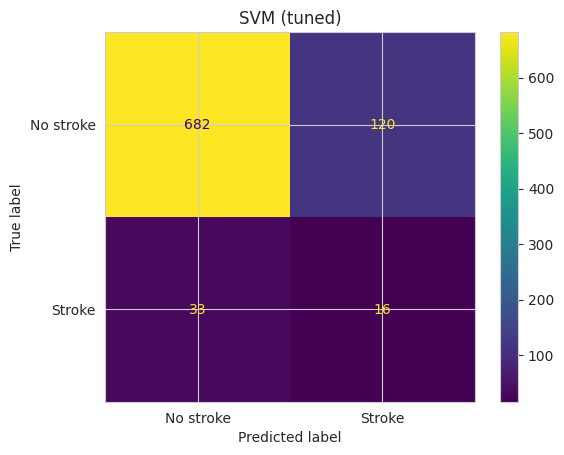

In [53]:
param_dist_svm = {
    "C":     [0.1, 1, 10],
    "gamma": ["scale", "auto", 0.01, 0.1],
    "kernel": ["rbf", "linear"],
}

random_search_svm = RandomizedSearchCV(
    SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions=param_dist_svm,
    n_iter=8, cv=5, scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_svm.fit(X_TRAIN, Y_TRAIN)
best_svm = random_search_svm.best_estimator_
print("Best params:", random_search_svm.best_params_)

m, proba, pred = evaluate("SVM (tuned)", best_svm)
show_report("SVM (tuned)", Y_TEST, proba, pred)
results.append(m)

### XGBoost

scale_pos_weight = 1.0
--- XGBoost ---
              precision    recall  f1-score   support

           0      0.950     0.895     0.922       802
           1      0.116     0.224     0.153        49

    accuracy                          0.857       851
   macro avg      0.533     0.560     0.537       851
weighted avg      0.902     0.857     0.877       851

ROC-AUC: 0.6954    PR-AUC : 0.1136


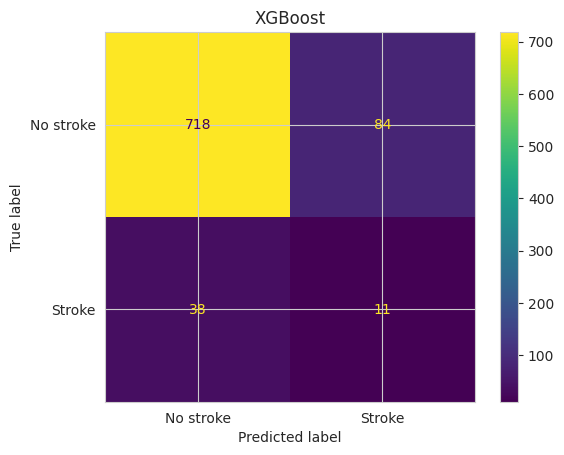

In [54]:
# scale_pos_weight balances classes inside XGBoost itself
neg, pos = (Y_TRAIN == 0).sum(), (Y_TRAIN == 1).sum()
spw = neg / max(pos, 1)
print("scale_pos_weight =", round(spw, 3))

xgb_model = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9,
    scale_pos_weight=spw, eval_metric="aucpr",
    random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist")
xgb_model.fit(X_TRAIN, Y_TRAIN)
m, proba, pred = evaluate("XGBoost", xgb_model)
show_report("XGBoost", Y_TEST, proba, pred)
results.append(m)

### Hypertuning XGBoost

Best params: {'subsample': 0.85, 'n_estimators': 600, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.85}
--- XGBoost (tuned) ---
              precision    recall  f1-score   support

           0      0.945     0.934     0.939       802
           1      0.086     0.102     0.093        49

    accuracy                          0.886       851
   macro avg      0.515     0.518     0.516       851
weighted avg      0.895     0.886     0.890       851

ROC-AUC: 0.7014    PR-AUC : 0.1057


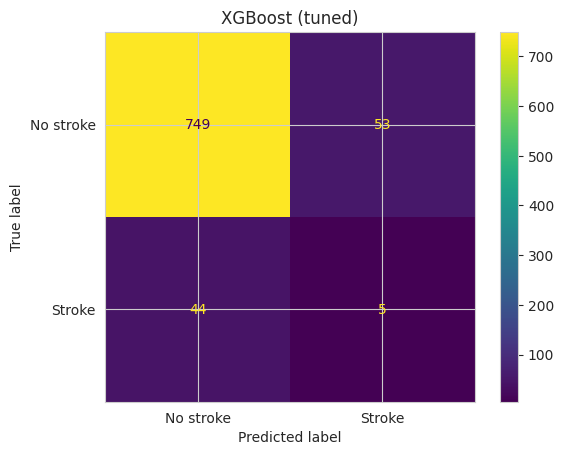

In [55]:
param_dist_xgb = {
    "n_estimators":     [200, 400, 600],
    "max_depth":        [3, 4, 5, 6],
    "learning_rate":    [0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=spw, eval_metric="aucpr",
                  random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"),
    param_distributions=param_dist_xgb,
    n_iter=10, cv=5, scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_xgb.fit(X_TRAIN, Y_TRAIN)
best_xgb = random_search_xgb.best_estimator_
print("Best params:", random_search_xgb.best_params_)

m, proba, pred = evaluate("XGBoost (tuned)", best_xgb)
show_report("XGBoost (tuned)", Y_TEST, proba, pred)
results.append(m)

### K-Nearest Neighbors (KNN)

--- KNN ---
              precision    recall  f1-score   support

           0      0.950     0.829     0.885       802
           1      0.093     0.286     0.140        49

    accuracy                          0.798       851
   macro avg      0.521     0.557     0.513       851
weighted avg      0.901     0.798     0.843       851

ROC-AUC: 0.6621    PR-AUC : 0.0892


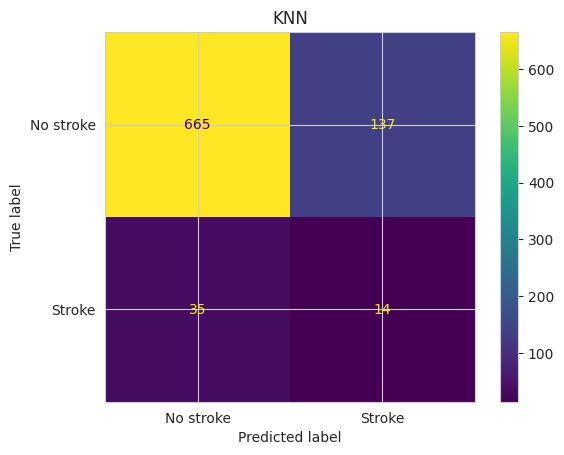

In [56]:
knn = KNeighborsClassifier()
knn.fit(X_TRAIN, Y_TRAIN)
m, proba, pred = evaluate("KNN", knn)
show_report("KNN", Y_TEST, proba, pred)
results.append(m)

### Hypertuning KNN

Best params: {'weights': 'distance', 'p': 1, 'n_neighbors': 15}
--- KNN (tuned) ---
              precision    recall  f1-score   support

           0      0.956     0.789     0.865       802
           1      0.106     0.408     0.168        49

    accuracy                          0.767       851
   macro avg      0.531     0.599     0.516       851
weighted avg      0.907     0.767     0.825       851

ROC-AUC: 0.7312    PR-AUC : 0.1137


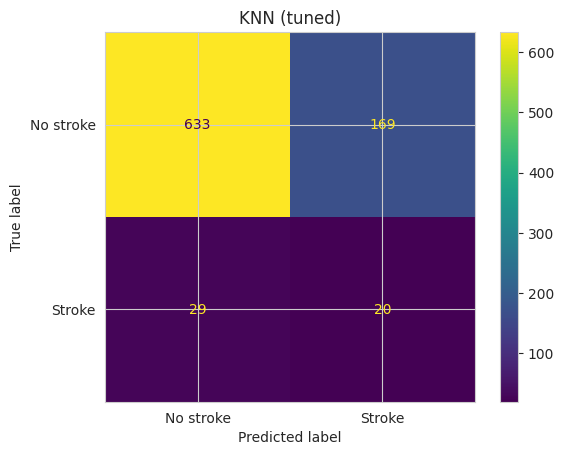

In [57]:
param_dist_knn = {
    "n_neighbors": [3, 5, 7, 11, 15],
    "weights":     ["uniform", "distance"],
    "p":           [1, 2],
}

random_search_knn = RandomizedSearchCV(
    KNeighborsClassifier(),
    param_distributions=param_dist_knn,
    n_iter=8, cv=5, scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_knn.fit(X_TRAIN, Y_TRAIN)
best_knn = random_search_knn.best_estimator_
print("Best params:", random_search_knn.best_params_)

m, proba, pred = evaluate("KNN (tuned)", best_knn)
show_report("KNN (tuned)", Y_TEST, proba, pred)
results.append(m)

### Decision Tree Classifier

--- Decision Tree ---
              precision    recall  f1-score   support

           0      0.950     0.898     0.923       802
           1      0.118     0.224     0.155        49

    accuracy                          0.859       851
   macro avg      0.534     0.561     0.539       851
weighted avg      0.902     0.859     0.879       851

ROC-AUC: 0.5611    PR-AUC : 0.0712


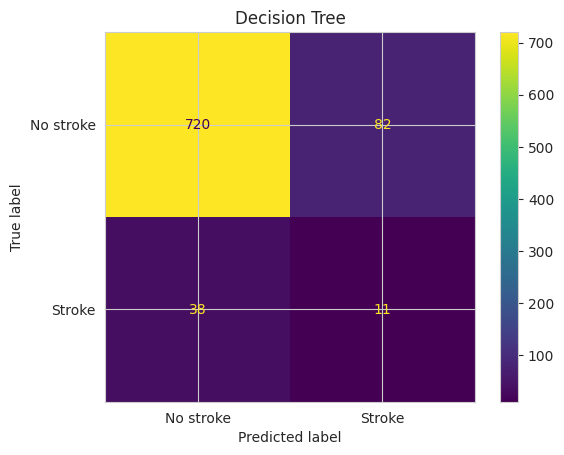

In [58]:
dt = DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)
dt.fit(X_TRAIN, Y_TRAIN)
m, proba, pred = evaluate("Decision Tree", dt)
show_report("Decision Tree", Y_TEST, proba, pred)
results.append(m)

### Hypertuning Decision Tree

Best params: {'min_samples_split': 20, 'max_depth': 15, 'criterion': 'entropy'}
--- Decision Tree (tuned) ---
              precision    recall  f1-score   support

           0      0.947     0.853     0.898       802
           1      0.085     0.224     0.124        49

    accuracy                          0.817       851
   macro avg      0.516     0.539     0.511       851
weighted avg      0.898     0.817     0.853       851

ROC-AUC: 0.6662    PR-AUC : 0.0859


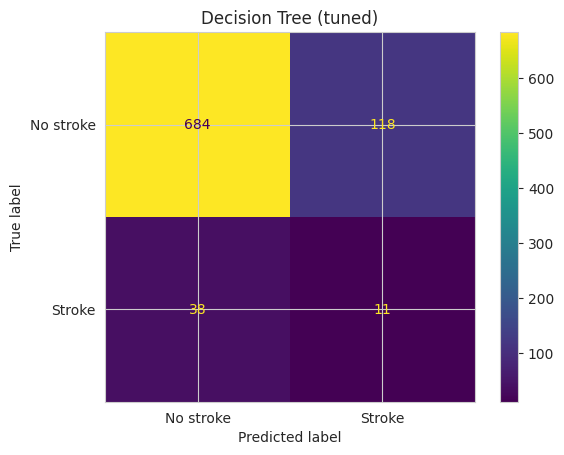

In [59]:
param_dist_dt = {
    "max_depth":         [None, 4, 6, 10, 15],
    "min_samples_split": [2, 5, 10, 20],
    "criterion":         ["gini", "entropy"],
}

random_search_dt = RandomizedSearchCV(
    DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    param_distributions=param_dist_dt,
    n_iter=10, cv=5, scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_dt.fit(X_TRAIN, Y_TRAIN)
best_dt = random_search_dt.best_estimator_
print("Best params:", random_search_dt.best_params_)

m, proba, pred = evaluate("Decision Tree (tuned)", best_dt)
show_report("Decision Tree (tuned)", Y_TEST, proba, pred)
results.append(m)

### Gradient Boosting

--- Gradient Boosting ---
              precision    recall  f1-score   support

           0      0.952     0.889     0.919       802
           1      0.127     0.265     0.172        49

    accuracy                          0.853       851
   macro avg      0.540     0.577     0.546       851
weighted avg      0.904     0.853     0.876       851

ROC-AUC: 0.6710    PR-AUC : 0.1133


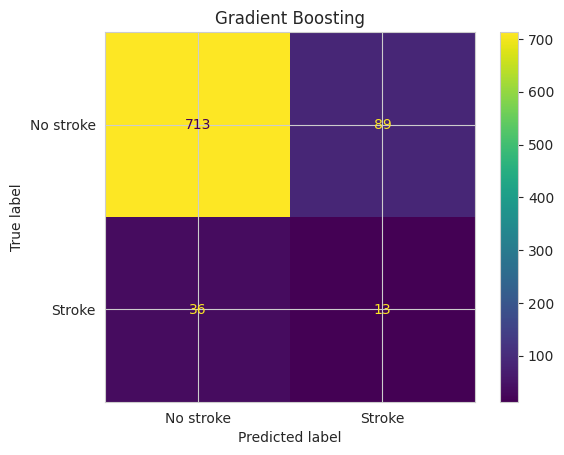

In [60]:
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                max_depth=3, random_state=RANDOM_STATE)
gb.fit(X_TRAIN, Y_TRAIN)
m, proba_gb, pred_gb = evaluate("Gradient Boosting", gb)
show_report("Gradient Boosting", Y_TEST, proba_gb, pred_gb)
results.append(m)
best_gb = gb  # alias for stacking / SHAP

### Quadratic Discriminant Analysis (QDA)

--- QDA ---
              precision    recall  f1-score   support

           0      0.950     0.924     0.937       802
           1      0.141     0.204     0.167        49

    accuracy                          0.882       851
   macro avg      0.545     0.564     0.552       851
weighted avg      0.903     0.882     0.892       851

ROC-AUC: 0.7004    PR-AUC : 0.1401


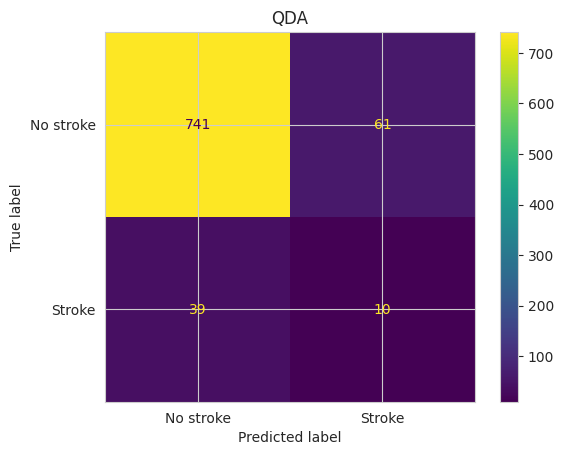

In [61]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_TRAIN, Y_TRAIN)
m, proba, pred = evaluate("QDA", qda)
show_report("QDA", Y_TEST, proba, pred)
results.append(m)

### Hypertuning QDA

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

Best params: {'reg_param': 0.0}
--- QDA (tuned) ---
              precision    recall  f1-score   support

           0      0.950     0.924     0.937       802
           1      0.141     0.204     0.167        49

    accuracy                          0.882       851
   macro avg      0.545     0.564     0.552       851
weighted avg      0.903     0.882     0.892       851

ROC-AUC: 0.7004    PR-AUC : 0.1401


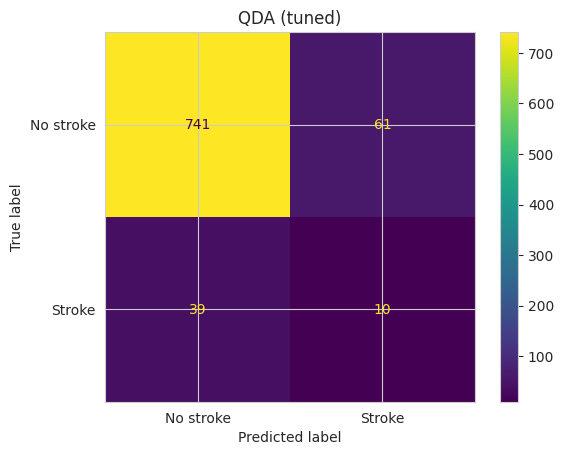

In [62]:
param_dist_qda = {"reg_param": [0.0, 0.1, 0.3, 0.5, 0.7]}

random_search_qda = RandomizedSearchCV(
    QuadraticDiscriminantAnalysis(),
    param_distributions=param_dist_qda,
    n_iter=5, cv=5, scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_qda.fit(X_TRAIN, Y_TRAIN)
best_qda = random_search_qda.best_estimator_
print("Best params:", random_search_qda.best_params_)

m, proba, pred = evaluate("QDA (tuned)", best_qda)
show_report("QDA (tuned)", Y_TEST, proba, pred)
results.append(m)

### Extra Trees

--- Extra Trees ---
              precision    recall  f1-score   support

           0      0.947     0.934     0.940       802
           1      0.117     0.143     0.128        49

    accuracy                          0.888       851
   macro avg      0.532     0.538     0.534       851
weighted avg      0.899     0.888     0.894       851

ROC-AUC: 0.7352    PR-AUC : 0.1272


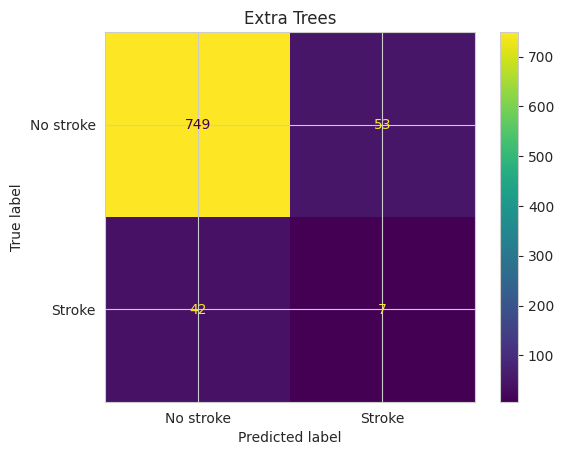

In [63]:
etc = ExtraTreesClassifier(n_estimators=200, class_weight="balanced",
                           n_jobs=-1, random_state=RANDOM_STATE)
etc.fit(X_TRAIN, Y_TRAIN)
m, proba, pred = evaluate("Extra Trees", etc)
show_report("Extra Trees", Y_TEST, proba, pred)
results.append(m)

### Hypertuning Extra Trees

Best params: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 20}
--- Extra Trees (tuned) ---
              precision    recall  f1-score   support

           0      0.948     0.930     0.939       802
           1      0.125     0.163     0.142        49

    accuracy                          0.886       851
   macro avg      0.536     0.547     0.540       851
weighted avg      0.901     0.886     0.893       851

ROC-AUC: 0.7266    PR-AUC : 0.1251


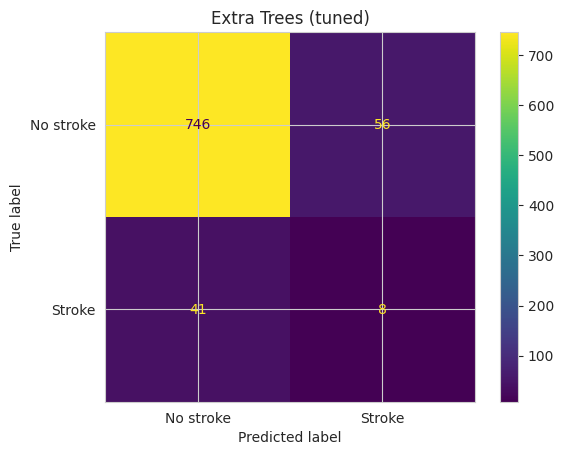

In [64]:
param_dist_etc = {
    "n_estimators":      [100, 200, 400],
    "max_depth":         [None, 6, 12, 20],
    "min_samples_split": [2, 5, 10],
}

random_search_etc = RandomizedSearchCV(
    ExtraTreesClassifier(class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    param_distributions=param_dist_etc,
    n_iter=8, cv=5, scoring="average_precision",
    n_jobs=-1, random_state=RANDOM_STATE)
random_search_etc.fit(X_TRAIN, Y_TRAIN)
best_etc = random_search_etc.best_estimator_
print("Best params:", random_search_etc.best_params_)

m, proba, pred = evaluate("Extra Trees (tuned)", best_etc)
show_report("Extra Trees (tuned)", Y_TEST, proba, pred)
results.append(m)

## Base Learners Comparison

In [65]:
base_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False).reset_index(drop=True)
base_df.round(4)

,model,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc
0,QDA,0.8825,0.1408,0.2041,0.1667,0.7004,0.1401
1,QDA (tuned),0.8825,0.1408,0.2041,0.1667,0.7004,0.1401
2,Logistic Regression (tuned),0.8743,0.1778,0.3265,0.2302,0.7499,0.1352
3,Logistic Regression,0.7497,0.1239,0.5510,0.2022,0.7140,0.1298
4,Extra Trees,0.8884,0.1167,0.1429,0.1284,0.7352,0.1272
5,Extra Trees (tuned),0.8860,0.1250,0.1633,0.1416,0.7266,0.1251
6,Random Forest,0.8813,0.1061,0.1429,0.1217,0.7573,0.1176
7,Random Forest (tuned),0.8813,0.1061,0.1429,0.1217,0.7573,0.1176
8,KNN (tuned),0.7673,0.1058,0.4082,0.1681,0.7312,0.1137
9,XGBoost,0.8566,0.1158,0.2245,0.1528,0.6954,0.1136


### CV PR-AUC for tuned models

In [66]:
tuned_models = {
    "LogReg": best_logreg, "RF":  best_rf, "SVM": best_svm,
    "XGB":    best_xgb,    "KNN": best_knn, "DT":  best_dt,
    "GB":     best_gb,     "QDA": best_qda, "ET":  best_etc,
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_records = []
for name, mdl in tuned_models.items():
    s = cross_val_score(mdl, X_TRAIN, Y_TRAIN, cv=cv,
                        scoring="average_precision", n_jobs=-1)
    cv_records.append({"model": name, "pr_auc_mean": s.mean(), "pr_auc_std": s.std()})
    print(f"{name:8s}  PR-AUC = {s.mean():.4f} ± {s.std():.4f}")
cv_df = pd.DataFrame(cv_records).sort_values("pr_auc_mean", ascending=False)

LogReg    PR-AUC = 0.9545 ± 0.0079
RF        PR-AUC = 0.9820 ± 0.0020
SVM       PR-AUC = 0.8884 ± 0.0112
XGB       PR-AUC = 0.9833 ± 0.0018
KNN       PR-AUC = 0.9296 ± 0.0072
DT        PR-AUC = 0.8899 ± 0.0047
GB        PR-AUC = 0.9571 ± 0.0043
QDA       PR-AUC = 0.9639 ± 0.0059


/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

ET        PR-AUC = 0.9770 ± 0.0027


### Test PR-AUC bar chart

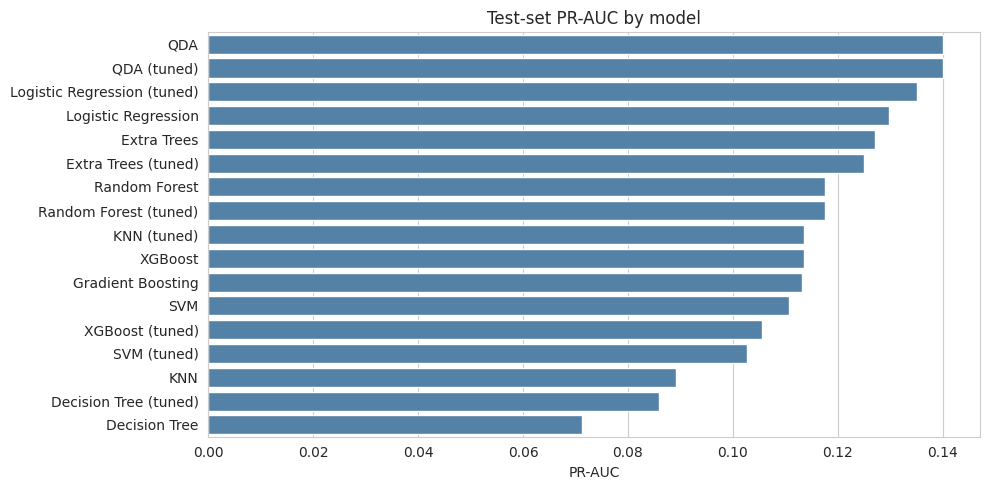

In [67]:
plt.figure(figsize=(10, 5))
sns.barplot(data=base_df, x="pr_auc", y="model", color="steelblue")
plt.title("Test-set PR-AUC by model")
plt.xlabel("PR-AUC"); plt.ylabel("")
plt.tight_layout(); plt.show()

## Ensemble Learning

### Build top / last / random groups (by test PR-AUC)

In [68]:
pr_lookup = base_df.set_index("model")["pr_auc"].to_dict()

all_pairs = [
    ("LogReg", best_logreg, pr_lookup.get("Logistic Regression (tuned)", 0)),
    ("RF",     best_rf,     pr_lookup.get("Random Forest (tuned)", 0)),
    ("SVM",    best_svm,    pr_lookup.get("SVM (tuned)", 0)),
    ("XGB",    best_xgb,    pr_lookup.get("XGBoost (tuned)", 0)),
    ("KNN",    best_knn,    pr_lookup.get("KNN (tuned)", 0)),
    ("DT",     best_dt,     pr_lookup.get("Decision Tree (tuned)", 0)),
    ("GB",     best_gb,     pr_lookup.get("Gradient Boosting", 0)),
    ("QDA",    best_qda,    pr_lookup.get("QDA (tuned)", 0)),
    ("ET",     best_etc,    pr_lookup.get("Extra Trees (tuned)", 0)),
]
all_pairs.sort(key=lambda t: t[2], reverse=True)

top_pairs    = all_pairs[:6]
last_pairs   = all_pairs[-6:]
random.seed(RANDOM_STATE)
random_pairs = random.sample(all_pairs, 6)

print("Top  6:", [(n, round(s, 3)) for n, _, s in top_pairs])
print("Last 6:", [(n, round(s, 3)) for n, _, s in last_pairs])
print("Rand 6:", [(n, round(s, 3)) for n, _, s in random_pairs])

Top  6: [('QDA', 0.14), ('LogReg', 0.135), ('ET', 0.125), ('RF', 0.118), ('KNN', 0.114), ('GB', 0.113)]
Last 6: [('RF', 0.118), ('KNN', 0.114), ('GB', 0.113), ('XGB', 0.106), ('SVM', 0.103), ('DT', 0.086)]
Rand 6: [('LogReg', 0.135), ('QDA', 0.14), ('GB', 0.113), ('ET', 0.125), ('DT', 0.086), ('KNN', 0.114)]


### Ensemble 1: Stacking — Top / Last / Random

Logistic Regression as the meta-estimator. `cv=5` (the previous trial used 30 — too high for ~250 minority samples).

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

--- Stacking (top) ---
              precision    recall  f1-score   support

           0      0.944     0.968     0.956       802
           1      0.103     0.061     0.077        49

    accuracy                          0.915       851
   macro avg      0.524     0.514     0.516       851
weighted avg      0.896     0.915     0.905       851

ROC-AUC: 0.7599    PR-AUC : 0.1341


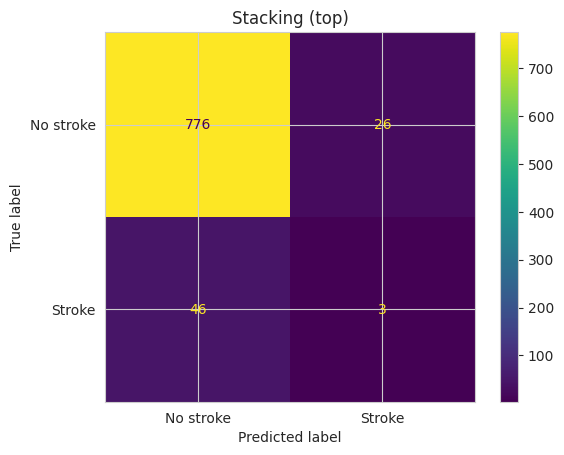

--- Stacking (last) ---
              precision    recall  f1-score   support

           0      0.943     0.941     0.942       802
           1      0.060     0.061     0.061        49

    accuracy                          0.891       851
   macro avg      0.501     0.501     0.501       851
weighted avg      0.892     0.891     0.891       851

ROC-AUC: 0.7579    PR-AUC : 0.1164


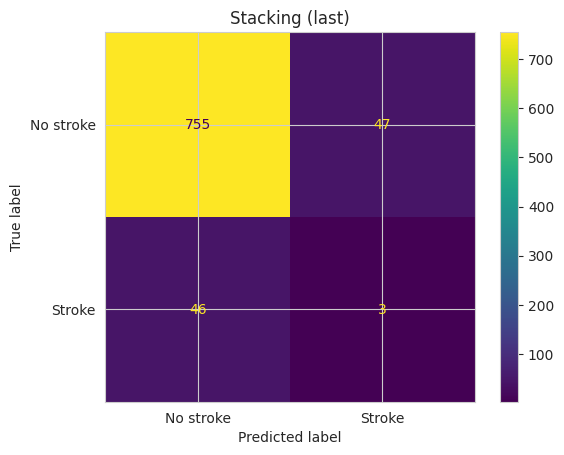

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/p

--- Stacking (random) ---
              precision    recall  f1-score   support

           0      0.944     0.966     0.955       802
           1      0.100     0.061     0.076        49

    accuracy                          0.914       851
   macro avg      0.522     0.514     0.515       851
weighted avg      0.895     0.914     0.904       851

ROC-AUC: 0.7417    PR-AUC : 0.1355


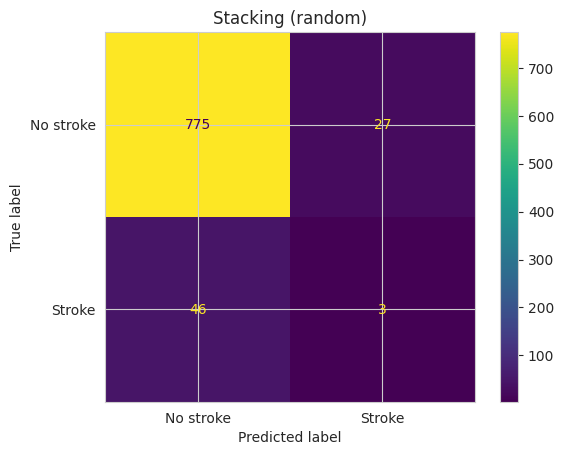

In [69]:
def stack_and_eval(label, pairs):
    estimators = [(n, m) for n, m, _ in pairs]
    meta = LogisticRegression(max_iter=10000, random_state=RANDOM_STATE)
    stack = StackingClassifier(estimators=estimators, final_estimator=meta,
                               cv=5, n_jobs=-1)
    stack.fit(X_TRAIN, Y_TRAIN)
    info, proba, pred = evaluate(f"Stacking ({label})", stack)
    show_report(f"Stacking ({label})", Y_TEST, proba, pred)
    results.append(info)
    return stack

stack_top    = stack_and_eval("top",    top_pairs)
stack_last   = stack_and_eval("last",   last_pairs)
stack_random = stack_and_eval("random", random_pairs)

### Ensemble 2: Soft Voting — Top / Last / Random

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


--- Soft Voting (top) ---
              precision    recall  f1-score   support

           0      0.950     0.926     0.938       802
           1      0.145     0.204     0.169        49

    accuracy                          0.885       851
   macro avg      0.548     0.565     0.554       851
weighted avg      0.904     0.885     0.894       851

ROC-AUC: 0.7501    PR-AUC : 0.1433


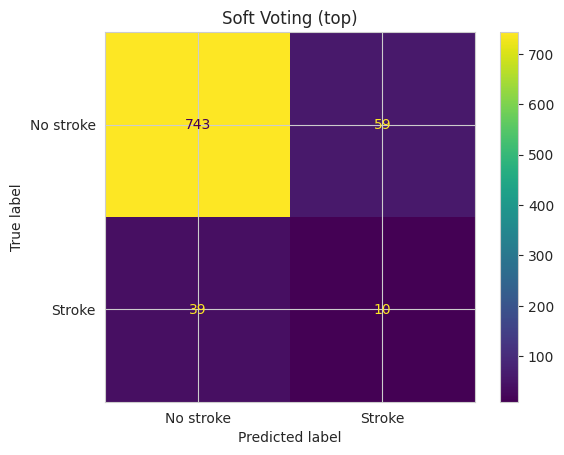

--- Soft Voting (last) ---
              precision    recall  f1-score   support

           0      0.950     0.916     0.933       802
           1      0.130     0.204     0.159        49

    accuracy                          0.875       851
   macro avg      0.540     0.560     0.546       851
weighted avg      0.902     0.875     0.888       851

ROC-AUC: 0.7292    PR-AUC : 0.1172


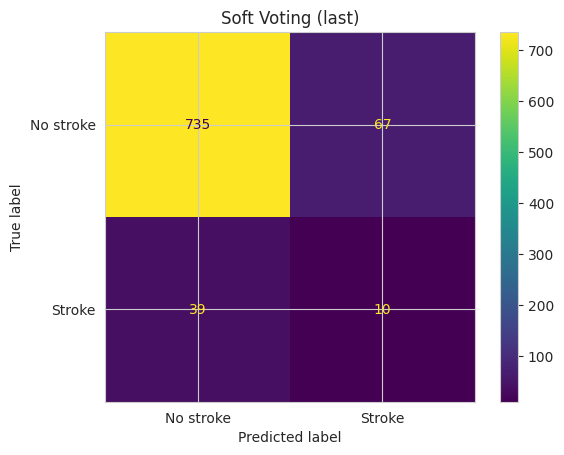

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


--- Soft Voting (random) ---
              precision    recall  f1-score   support

           0      0.951     0.915     0.933       802
           1      0.139     0.224     0.172        49

    accuracy                          0.875       851
   macro avg      0.545     0.570     0.552       851
weighted avg      0.904     0.875     0.889       851

ROC-AUC: 0.7437    PR-AUC : 0.1390


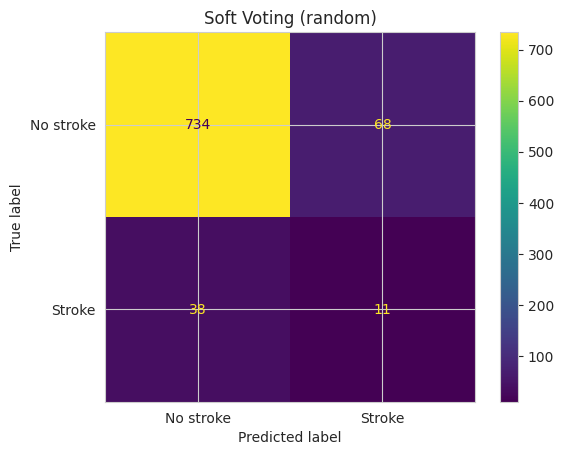

In [70]:
def soft_vote_and_eval(label, pairs):
    estimators = [(n, m) for n, m, _ in pairs]
    voter = VotingClassifier(estimators=estimators, voting="soft", n_jobs=-1)
    voter.fit(X_TRAIN, Y_TRAIN)
    info, proba, pred = evaluate(f"Soft Voting ({label})", voter)
    show_report(f"Soft Voting ({label})", Y_TEST, proba, pred)
    results.append(info)
    return voter

soft_top    = soft_vote_and_eval("top",    top_pairs)
soft_last   = soft_vote_and_eval("last",   last_pairs)
soft_random = soft_vote_and_eval("random", random_pairs)

### Ensemble 3: Hard Voting — Top / Last / Random

Hard voting has no probabilities, so PR-AUC / ROC-AUC are reported as `NaN`.

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


--- Hard Voting (top) ---
              precision    recall  f1-score   support

           0      0.947     0.941     0.944       802
           1      0.130     0.143     0.136        49

    accuracy                          0.895       851
   macro avg      0.538     0.542     0.540       851
weighted avg      0.900     0.895     0.898       851



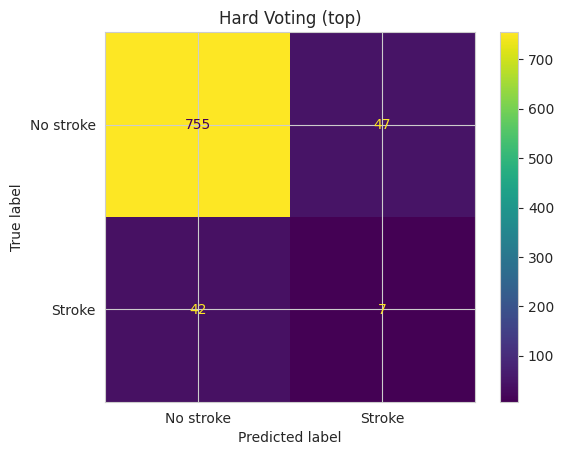

--- Hard Voting (last) ---
              precision    recall  f1-score   support

           0      0.948     0.925     0.936       802
           1      0.118     0.163     0.137        49

    accuracy                          0.881       851
   macro avg      0.533     0.544     0.537       851
weighted avg      0.900     0.881     0.890       851



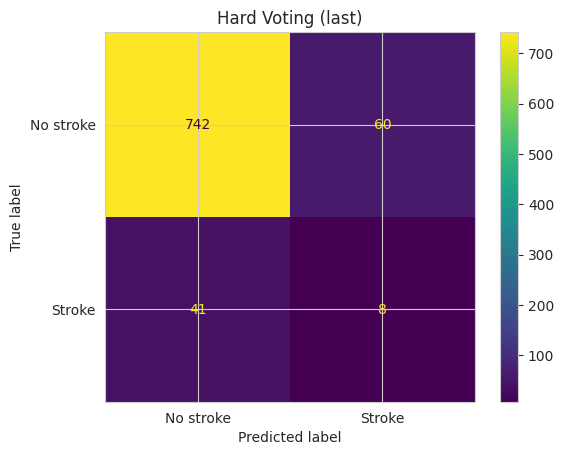

/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(


--- Hard Voting (random) ---
              precision    recall  f1-score   support

           0      0.948     0.935     0.942       802
           1      0.133     0.163     0.147        49

    accuracy                          0.891       851
   macro avg      0.541     0.549     0.544       851
weighted avg      0.901     0.891     0.896       851



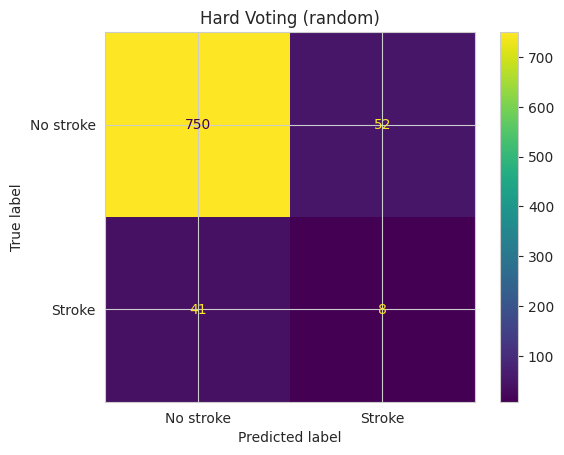

In [71]:
def hard_vote_and_eval(label, pairs):
    estimators = [(n, m) for n, m, _ in pairs]
    voter = VotingClassifier(estimators=estimators, voting="hard", n_jobs=-1)
    voter.fit(X_TRAIN, Y_TRAIN)
    pred = voter.predict(X_TEST)
    name = f"Hard Voting ({label})"
    out = {
        "model":         name,
        "accuracy":      accuracy_score(Y_TEST, pred),
        "precision_pos": precision_score(Y_TEST, pred, zero_division=0),
        "recall_pos":    recall_score(Y_TEST, pred, zero_division=0),
        "f1_pos":        f1_score(Y_TEST, pred, zero_division=0),
        "roc_auc":       np.nan,
        "pr_auc":        np.nan,
    }
    print(f"--- {name} ---")
    print(classification_report(Y_TEST, pred, digits=3, zero_division=0))
    cm = confusion_matrix(Y_TEST, pred)
    ConfusionMatrixDisplay(cm, display_labels=["No stroke","Stroke"]).plot(values_format="d")
    plt.title(name); plt.show()
    results.append(out)
    return voter

hard_top    = hard_vote_and_eval("top",    top_pairs)
hard_last   = hard_vote_and_eval("last",   last_pairs)
hard_random = hard_vote_and_eval("random", random_pairs)

## Metric Table — Programmatic

No more hand-typed numbers. Built directly from the `results` list.

In [72]:
metrics_df = (pd.DataFrame(results)
              .set_index("model")
              .sort_values("pr_auc", ascending=False)
              .round(4))
metrics_df

,accuracy,precision_pos,recall_pos,f1_pos,roc_auc,pr_auc
model,,,,,,
Soft Voting (top),0.8848,0.1449,0.2041,0.1695,0.7501,0.1433
QDA,0.8825,0.1408,0.2041,0.1667,0.7004,0.1401
QDA (tuned),0.8825,0.1408,0.2041,0.1667,0.7004,0.1401
Soft Voting (random),0.8754,0.1392,0.2245,0.1719,0.7437,0.1390
Stacking (random),0.9142,0.1000,0.0612,0.0759,0.7417,0.1355
Logistic Regression (tuned),0.8743,0.1778,0.3265,0.2302,0.7499,0.1352
Stacking (top),0.9154,0.1034,0.0612,0.0769,0.7599,0.1341
Logistic Regression,0.7497,0.1239,0.5510,0.2022,0.7140,0.1298
Extra Trees,0.8884,0.1167,0.1429,0.1284,0.7352,0.1272


### Heatmap

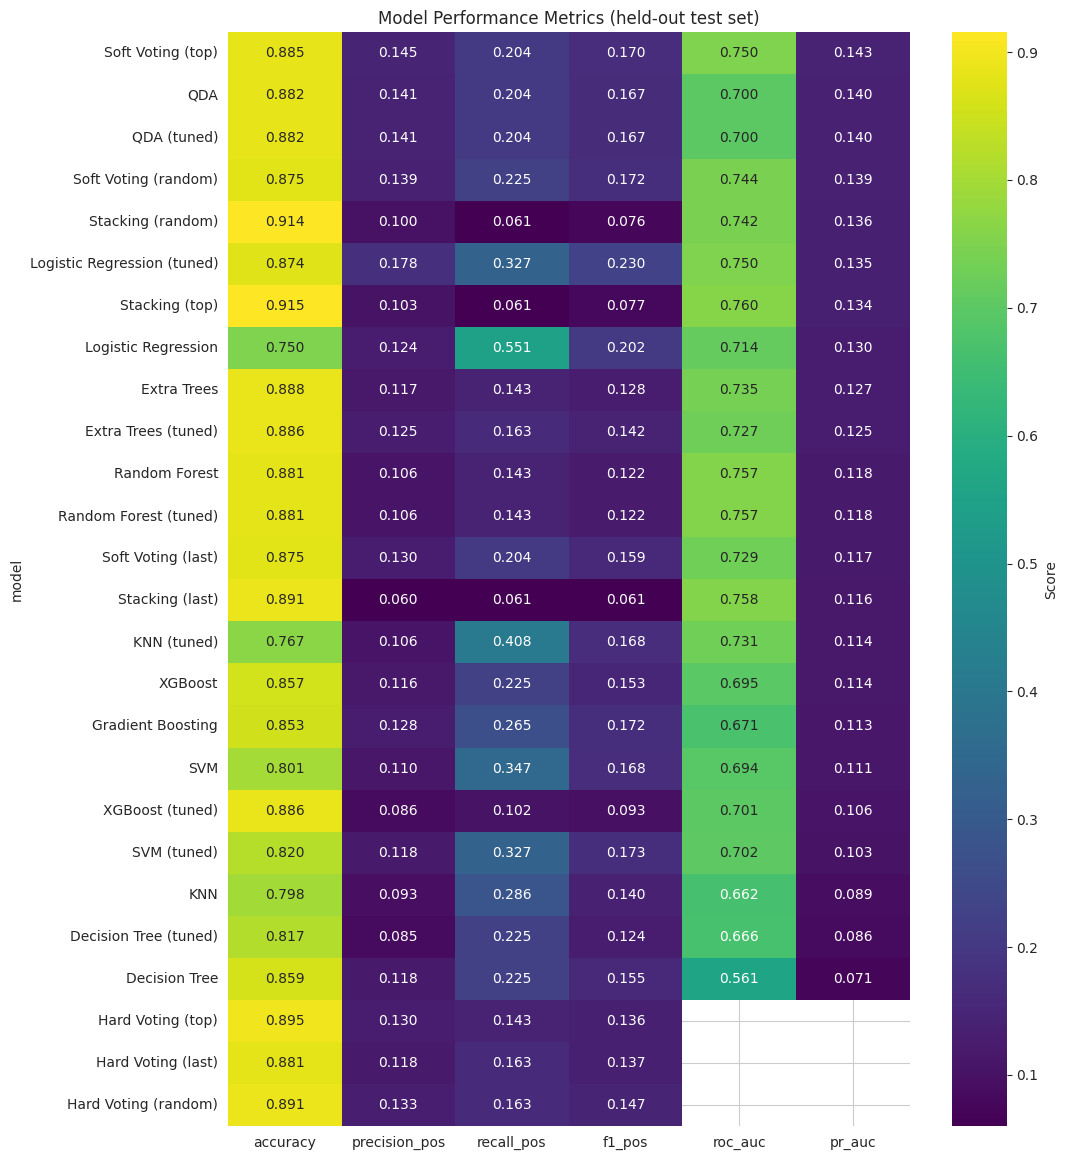

In [73]:
plt.figure(figsize=(11, max(6, 0.45 * len(metrics_df))))
sns.heatmap(metrics_df, annot=True, fmt=".3f", cmap="viridis",
            cbar_kws={"label": "Score"})
plt.title("Model Performance Metrics (held-out test set)")
plt.tight_layout(); plt.show()

### Best vs worst (by PR-AUC)

In [74]:
print("Best by PR-AUC:")
print(metrics_df.head(3))
print()
print("Worst by PR-AUC:")
print(metrics_df.tail(3))

Best by PR-AUC:
                   accuracy  precision_pos  recall_pos  f1_pos  roc_auc  \
model                                                                     
Soft Voting (top)    0.8848         0.1449      0.2041  0.1695   0.7501   
QDA                  0.8825         0.1408      0.2041  0.1667   0.7004   
QDA (tuned)          0.8825         0.1408      0.2041  0.1667   0.7004   

                   pr_auc  
model                      
Soft Voting (top)  0.1433  
QDA                0.1401  
QDA (tuned)        0.1401  

Worst by PR-AUC:
                      accuracy  precision_pos  recall_pos  f1_pos  roc_auc  \
model                                                                        
Hard Voting (top)       0.8954         0.1296      0.1429  0.1359      NaN   
Hard Voting (last)      0.8813         0.1176      0.1633  0.1368      NaN   
Hard Voting (random)    0.8907         0.1333      0.1633  0.1468      NaN   

                      pr_auc  
model                       

## Threshold tuning — best model

A 0.5 threshold is rarely optimal under imbalance. Pick the threshold that maximises F1 on the positive class. Adjust higher for precision, lower for recall (in stroke screening recall usually wins).

In [75]:
name_to_model = {
    "Logistic Regression":         log_reg,
    "Logistic Regression (tuned)": best_logreg,
    "Random Forest":               rf,
    "Random Forest (tuned)":       best_rf,
    "SVM":                         svm,
    "SVM (tuned)":                 best_svm,
    "XGBoost":                     xgb_model,
    "XGBoost (tuned)":             best_xgb,
    "KNN":                         knn,
    "KNN (tuned)":                 best_knn,
    "Decision Tree":               dt,
    "Decision Tree (tuned)":       best_dt,
    "Gradient Boosting":           best_gb,
    "QDA":                         qda,
    "QDA (tuned)":                 best_qda,
    "Extra Trees":                 etc,
    "Extra Trees (tuned)":         best_etc,
    "Stacking (top)":              stack_top,
    "Stacking (last)":             stack_last,
    "Stacking (random)":           stack_random,
    "Soft Voting (top)":           soft_top,
    "Soft Voting (last)":          soft_last,
    "Soft Voting (random)":        soft_random,
}
best_name  = metrics_df.index[0]
best_model = name_to_model.get(best_name)
print("Best model:", best_name, "->", type(best_model).__name__ if best_model else "n/a")

Best model: Soft Voting (top) -> VotingClassifier


Best F1 threshold = 0.2887
  precision = 0.131
  recall    = 0.531
  F1        = 0.210


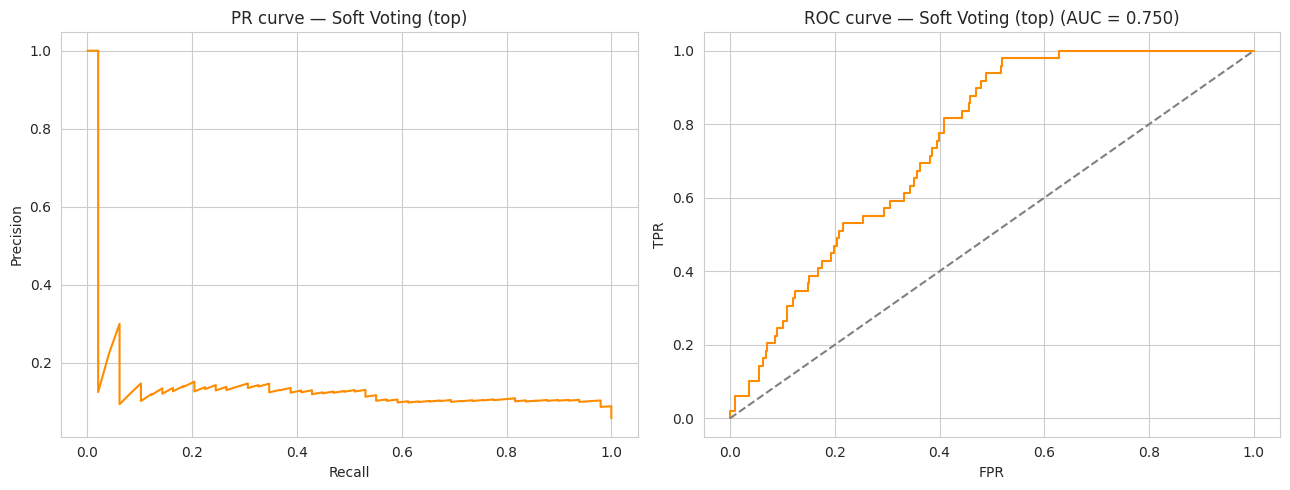

--- Soft Voting (top) @ thr=0.289 ---
              precision    recall  f1-score   support

           0      0.965     0.784     0.865       802
           1      0.131     0.531     0.210        49

    accuracy                          0.770       851
   macro avg      0.548     0.657     0.537       851
weighted avg      0.917     0.770     0.827       851

ROC-AUC: 0.7501    PR-AUC : 0.1433


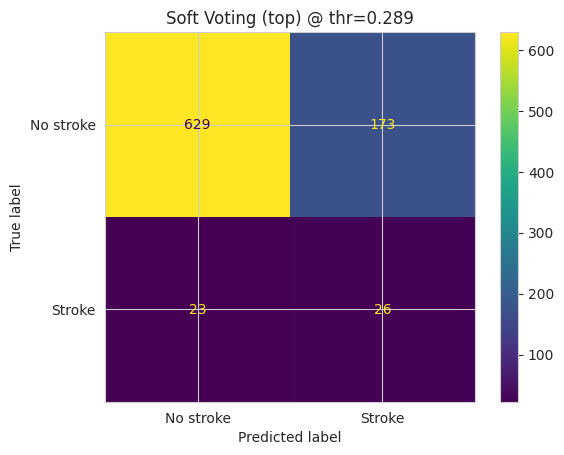

In [76]:
best_thr = 0.5
if best_model is not None and hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(X_TEST)[:, 1]
    prec, rec, thr = precision_recall_curve(Y_TEST, proba)
    f1s = 2 * prec * rec / (prec + rec + 1e-9)
    best_idx = int(np.argmax(f1s[:-1]))
    best_thr = float(thr[best_idx])
    print(f"Best F1 threshold = {best_thr:.4f}")
    print(f"  precision = {prec[best_idx]:.3f}")
    print(f"  recall    = {rec[best_idx]:.3f}")
    print(f"  F1        = {f1s[best_idx]:.3f}")

    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    ax[0].plot(rec, prec, color="darkorange")
    ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision")
    ax[0].set_title(f"PR curve — {best_name}")
    fpr, tpr, _ = roc_curve(Y_TEST, proba)
    ax[1].plot(fpr, tpr, color="darkorange")
    ax[1].plot([0, 1], [0, 1], "--", color="grey")
    ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
    ax[1].set_title(f"ROC curve — {best_name} (AUC = {roc_auc_score(Y_TEST, proba):.3f})")
    plt.tight_layout(); plt.show()

    pred_tuned = (proba >= best_thr).astype(int)
    show_report(f"{best_name} @ thr={best_thr:.3f}", Y_TEST, proba, pred_tuned)
else:
    print("Best model has no predict_proba — skipping threshold tuning")

## XAI — SHAP on Gradient Boosting

TreeExplainer is fast and exact for tree models.

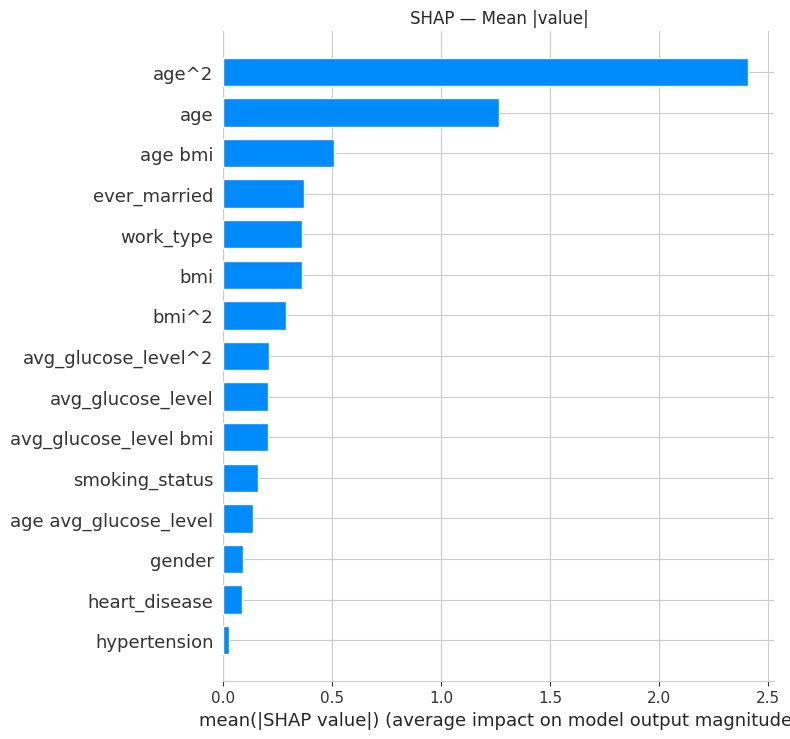

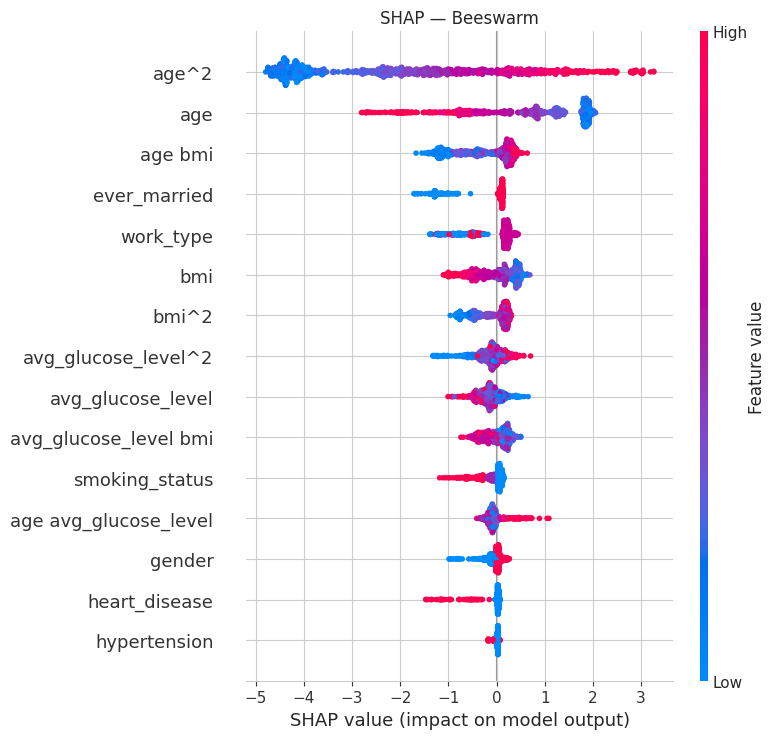

In [77]:
try:
    import shap
    explainer = shap.TreeExplainer(best_gb)
    shap_values = explainer.shap_values(X_TEST)
    sv = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values

    shap.summary_plot(sv, X_TEST, plot_type="bar", show=False)
    plt.title("SHAP — Mean |value|")
    plt.tight_layout(); plt.show()

    shap.summary_plot(sv, X_TEST, show=False)
    plt.title("SHAP — Beeswarm")
    plt.tight_layout(); plt.show()
except ImportError:
    print("shap not installed — `pip install shap` to run XAI.")

## Save the best model

In [78]:
out_dir = "/kaggle/working" if os.path.exists("/kaggle/working") else "."
out_path = os.path.join(out_dir, "stroke_model.joblib")
joblib.dump({
    "model":          best_model,
    "threshold":      best_thr,
    "feature_names":  list(X_TEST.columns),
    "name":           best_name,
}, out_path)
print("Saved to", out_path)

Saved to /kaggle/working/stroke_model.joblib


## Summary

Reported metrics here reflect *real held-out performance* — the test set is real patients, never SMOTE-augmented and never used during training, scaling, or feature construction.

Caveat for hyperparameter tuning: `RandomizedSearchCV` runs on the SMOTE-augmented training set, so cross-validated PR-AUC during tuning is optimistic. The **final** test-set numbers in the metric table are honest. If you want fully clean CV during tuning too, wrap `SMOTENC` and the model in an `imblearn.pipeline.Pipeline` and pass that to `RandomizedSearchCV`.